# Анализ взаимодействия между музыкальными элементами и эмоциями

**Датасет:** PANDA / TAFFC — 900 аудиоклипов (~30 сек), размечены по модели Рассела

| Папка | Индекс | Эмоция |
|-------|--------|--------|
| Q1    | 0      | Happy — радость (+Valence, +Arousal) |
| Q2    | 1      | Angry — гнев/напряжение (−Valence, +Arousal) |
| Q3    | 2      | Sad — грусть (−Valence, −Arousal) |
| Q4    | 3      | Relaxed — спокойствие (+Valence, −Arousal) |

**Цель:** Исследовать, как музыкальные характеристики (темп, тональность, громкость) влияют на восприятие эмоций.
**Задачи:**
1. Извлечь признаки из аудио: темп (BPM), среднюю громкость, частотный спектр.
2. Построить регрессионную модель (например, Random Forest) для оценки влияния признаков на эмоции.
3. Использовать SHAP для интерпретации важности признаков.
4. Визуализировать зависимости (например, график зависимости громкости от эмоции "гнев").

In [35]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import shap

from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

In [2]:
DATA_ROOT = Path('../data')

EMOTION_MAP = {
    'Q1': {'label': 'happy', 'index': 0, 'valence': +1, 'arousal': +1, 'color': '#F4D03F'},
    'Q2': {'label': 'angry', 'index': 1, 'valence': -1, 'arousal': +1, 'color': '#E74C3C'},
    'Q3': {'label': 'sad', 'index': 2, 'valence': -1, 'arousal': -1, 'color': '#5DADE2'},
    'Q4': {'label': 'relaxed', 'index': 3, 'valence': +1, 'arousal': -1, 'color': '#58D68D'},
}

COLORS = [EMOTION_MAP[q]['color'] for q in ['Q1', 'Q2', 'Q3', 'Q4']]
LABELS = [EMOTION_MAP[q]['label'] for q in ['Q1', 'Q2', 'Q3', 'Q4']]

total = 0
for folder, info in EMOTION_MAP.items():
    path = DATA_ROOT / folder
    if path.exists():
        files = list(path.glob('*.mp3')) + list(path.glob('*.wav'))
        count = len(files)
        total += count
        print(f'{folder} ({info["label"]}): {count:3d} файлов')
    else:
        print(f'{folder}: папка не найдена')
print(f'Итого: {total} файлов')

Q1 (happy): 225 файлов
Q2 (angry): 225 файлов
Q3 (sad): 225 файлов
Q4 (relaxed): 225 файлов
Итого: 900 файлов


## Извлечение признаков из аудио

Извлекаем следующие признаки:
- **Tempo (BPM)** - темп
- **Loudness (RMS)** - средняя громкость
- **Spectral Centroid** - центроид спектра ("яркость" звука)
- **Spectral Rolloff** - граница 85% энергии спектра
- **Spectral Bandwidth** - ширина спектра
- **Zero-Crossing Rate (ZCR)** - скорость пересечения нуля
- **MFCC 1–13** - мел-частотные кепстральные коэффициенты
- **Chroma** - хроматические признаки (тональность)
- **Valence / Arousal** - числовые координаты модели Рассела

In [3]:
def extract_features(file_path: str, sr: int = 22050, duration: float = 30.0) -> dict | None:
    """
    Извлекает музыкальные признаки из аудиофайла

    Args:
        file_path: путь к аудиофайлу (.mp3 или .wav)
        sr: частота дискретизации (по умолчанию 22050 Гц)
        duration: длительность  фрагмента в секундах
    
    Returns: 
        dict с признаками или None при ошибке
    """
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=duration, mono=True)

        features = {}

        # Темп
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features['tempo'] = float(np.asarray(tempo).flat[0])

        # Громкость (RMS)
        rms = librosa.feature.rms(y=y)
        features['loudness_mean'] = float(np.mean(rms))
        features['loudness_std'] = float(np.std(rms))
        
        # Спектральные признаки
        spec_centroid  = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
        spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)

        features['spectral_centroid_mean'] = float(np.mean(spec_centroid))
        features['spectral_rolloff_mean'] = float(np.mean(spec_rolloff))
        features['spectral_bandwidth_mean'] = float(np.mean(spec_bandwidth))

        # Zero-Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features['zcr_mean'] = float(np.mean(zcr))

        # MFCC (13 коэффициентов)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i, coef in enumerate(mfcc, 1):
            features[f'MFCC_{i}'] = float(np.mean(coef))

        # Chroma (12 полутонов)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features['chroma_mean'] = float(np.mean(chroma))
        features['chroma_std'] = float(np.std(chroma))

        return features

    except Exception as e:
        print(f'Ошибка при обработке {file_path}: {e}')
        return None

In [4]:
CACHE_FILE = Path('../data/features_cache.csv') # на случай, если уже была загрузка файлов, чтоб снова не загружать

if CACHE_FILE.exists():
    df = pd.read_csv(CACHE_FILE)
    print(f'Загружено {len(df)} строк, {len(df.columns)} столбцов')
else:
    records = []

    for folder, info in EMOTION_MAP.items():
        path = DATA_ROOT / folder
        if not path.exists():
            print(f'Папка {path} не найдена — пропускаем')
            continue

        files = sorted(list(path.glob('*.mp3')) + list(path.glob('*.wav')))
        print(f'\nОбрабатываем {folder} ({info["label"]}): {len(files)} файлов')

        for fp in tqdm(files, desc=f'{folder}', leave=False):
            feats = extract_features(str(fp))
            if feats is not None:
                feats['file'] = fp.name
                feats['folder'] = folder
                feats['emotion'] = info['label']
                feats['emotion_idx'] = info['index']
                feats['valence'] = info['valence']
                feats['arousal'] = info['arousal']
                records.append(feats)

    df = pd.DataFrame(records)
    df.to_csv(CACHE_FILE, index=False)
    print(f'\nПризнаки сохранены в {CACHE_FILE}')
    print(f'Итого: {len(df)} файлов обработано')

Загружено 900 строк, 28 столбцов


In [5]:
df.head(5)

,tempo,loudness_mean,loudness_std,spectral_centroid_mean,spectral_rolloff_mean,spectral_bandwidth_mean,zcr_mean,MFCC_1,MFCC_2,MFCC_3,...,MFCC_12,MFCC_13,chroma_mean,chroma_std,file,folder,emotion,emotion_idx,valence,arousal
0,99.384014,0.204127,0.073971,2146.940511,5213.201810,2685.679865,0.068459,-85.872467,93.539543,22.547556,...,-4.158273,-5.707183,0.378782,0.288813,MT0000040632.mp3,Q1,happy,0,1,1
1,129.199219,0.130548,0.043504,2736.586158,5603.332784,2575.917125,0.143797,-73.055061,76.041733,-4.589801,...,3.384572,-5.410607,0.369929,0.290237,MT0000082187.mp3,Q1,happy,0,1,1
2,161.499023,0.271291,0.091591,2715.342116,6037.113494,2830.498986,0.100305,-21.326622,74.553276,5.179873,...,0.224185,-3.908479,0.377025,0.299132,MT0000249842.mp3,Q1,happy,0,1,1
3,123.046875,0.173934,0.035406,1582.084074,3293.480085,2066.327765,0.069470,-90.921913,126.462753,1.253699,...,3.455256,-0.073436,0.296106,0.280895,MT0000364027.mp3,Q1,happy,0,1,1
4,92.285156,0.090475,0.040513,2102.834964,4383.640159,2184.293307,0.095860,-147.818329,106.715996,-14.053626,...,2.936568,-2.916559,0.347002,0.285603,MT0000392975.mp3,Q1,happy,0,1,1


## EDA

In [6]:
print('Распределение по эмоциям:')
print(df['emotion'].value_counts().to_string())

print('\nОписательная статистика ключевых признаков:')
df[['tempo', 'loudness_mean', 'spectral_centroid_mean', 'zcr_mean']].describe().round(3)

Распределение по эмоциям:
emotion
happy      225
angry      225
sad        225
relaxed    225

Описательная статистика ключевых признаков:


,tempo,loudness_mean,spectral_centroid_mean,zcr_mean
count,900.000,900.000,900.000,900.000
mean,120.302,0.144,2038.531,0.099
std,28.255,0.069,677.986,0.042
min,58.727,0.017,382.657,0.020
25%,99.384,0.093,1503.325,0.067
50%,117.454,0.132,2045.473,0.096
75%,135.999,0.190,2523.590,0.128
max,234.908,0.401,3633.572,0.250


Датасет содержит 900 аудиоклипов (по 225 на каждую эмоцию), классы полностью сбалансированы, смещения модели нет

- Темп: среднее ~120 BPM, диапазон 59–235. Охватывает как медленные (Sad/Relaxed), так и быстрые треки (Happy/Angry)
- Громкость: среднее 0.144, максимум 0.401 - большой разброс указывает на существенные различия в динамике между эмоциями.
- Спектральный центроид: ~2039 Гц в среднем, ожидаем, что у Happy и Angry значения выше, т.к. звук более "яркий"
- ZCR: среднее 0.099 - отражает шумность и ударные, важен для разделения Angry от спокойных классов

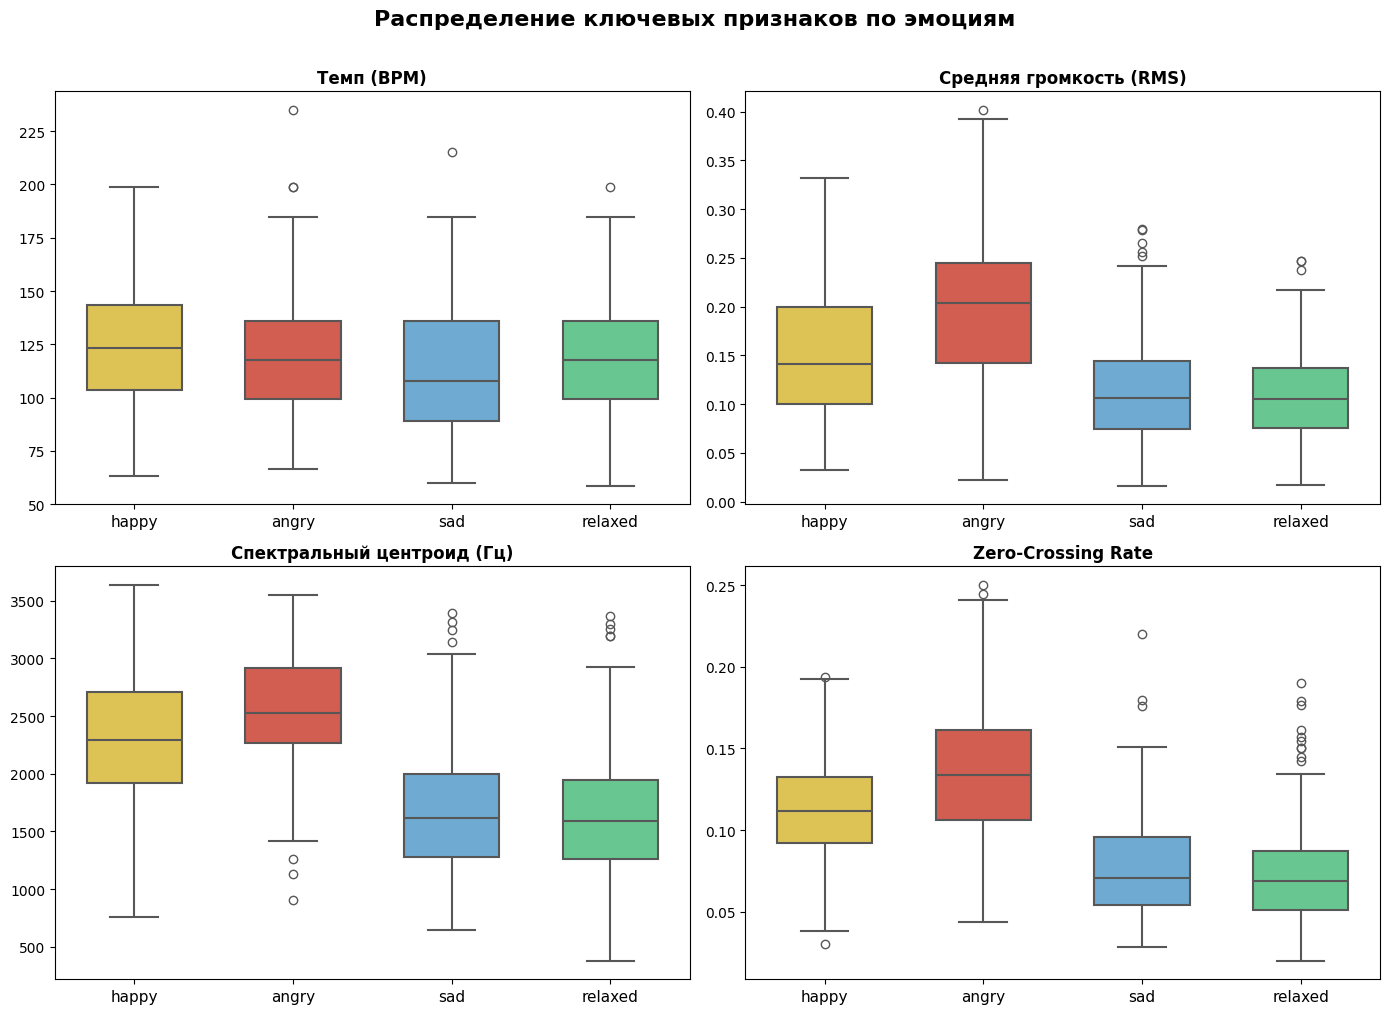

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределение ключевых признаков по эмоциям', fontsize=16, fontweight='bold', y=1.01)

features_to_plot = [
    ('tempo', 'Темп (BPM)'),
    ('loudness_mean', 'Средняя громкость (RMS)'),
    ('spectral_centroid_mean', 'Спектральный центроид (Гц)'),
    ('zcr_mean', 'Zero-Crossing Rate'),
]

emotion_order = ['happy', 'angry', 'sad', 'relaxed']
palette = {'happy': '#F4D03F', 'angry': '#E74C3C', 'sad': '#5DADE2', 'relaxed': '#58D68D'}

for ax, (feat, title) in zip(axes.flat, features_to_plot):
    sns.boxplot(data=df, x='emotion', y=feat, order=emotion_order, palette=palette, width=0.6, linewidth=1.5, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

- Темп: Happy, Angry и Relaxed имеют наиболее высокий медианный BPM (~120-125 BPM). Sad заметно медленнее (~105 BPM). Темп в одиночку эмоции не разделяет
- Громкость: Angry выделяется наибольшей медианной громкостью (~0.2) и широким разбросом - агрессивная музыка динамически непредсказуема. Relaxed ялвяется самым тихим классом
- Спектральный центроид: Happy и Angry имеют более высокую "яркость". Sad и Relaxed не такие яркие, имеют более приглушённый тембр
- ZCR: Angry лидирует по ZCR, что отражает большое количество ударных и резких звуков. У Relaxed ZCR минимальный, характерный для плавных протяжных звуков

Sad и Relaxed в целом очень похожи между собой, разделять их по ключевым признакам довльно тяжело

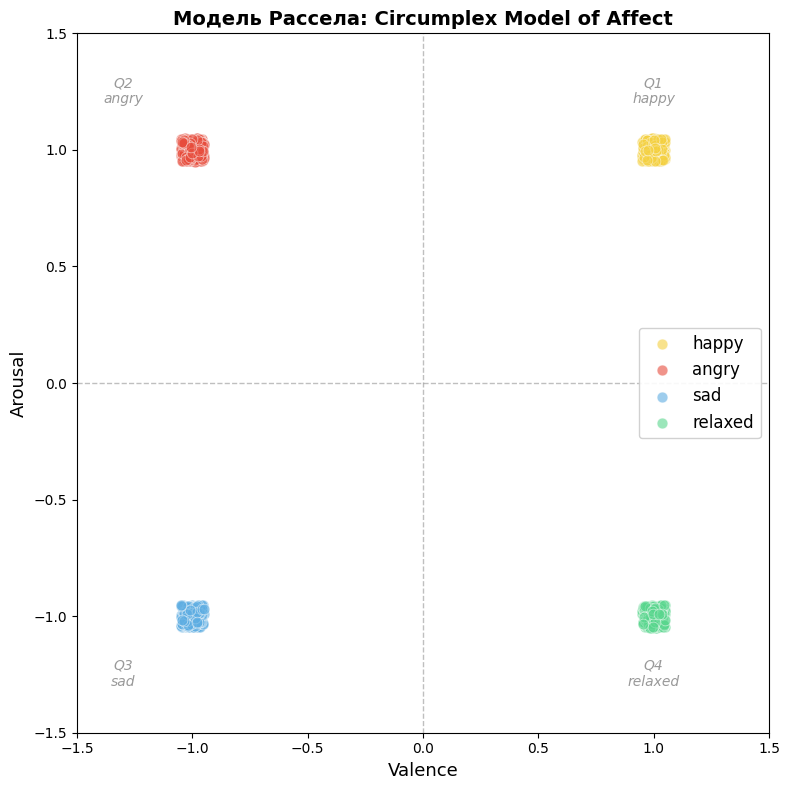

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

for folder, info in EMOTION_MAP.items():
    subset = df[df['folder'] == folder]
    # добавляем небольшой jitter для наглядности
    jitter = 0.05
    ax.scatter(
        subset['valence'] + np.random.uniform(-jitter, jitter, len(subset)),
        subset['arousal'] + np.random.uniform(-jitter, jitter, len(subset)),
        c=info['color'], label=f"{info['label']}",
        alpha=0.6, s=60, edgecolors='white', linewidths=0.5
    )

ax.axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Valence', fontsize=13)
ax.set_ylabel('Arousal', fontsize=13)
ax.set_title('Модель Рассела: Circumplex Model of Affect', fontsize=14, fontweight='bold')

for txt, xy in [('Q2\nangry', (-1.3, 1.2)), ('Q1\nhappy', (1.0, 1.2)),
                ('Q3\nsad', (-1.3, -1.3)), ('Q4\nrelaxed', (1.0, -1.3))]:
    ax.text(*xy, txt, fontsize=10, alpha=0.4, ha='center', style='italic')

ax.legend(fontsize=12, framealpha=0.9)
plt.tight_layout()
plt.show()

- Четыре квадранта чётко разделены по знаку Valence/Arousal согласно теоретической модели Расселла
- **Happy** (+V, +A) и **Angry** (−V, +A) - оба высокоэнергетичны, различаются знаком эмоции. Это объясняет их акустическое сходство по темпу
- **Relaxed** (+V, −A) и **Sad** (−V, −A) - низкая энергия, противоположная валентность, тихие и медленные

## Корреляционный анализ

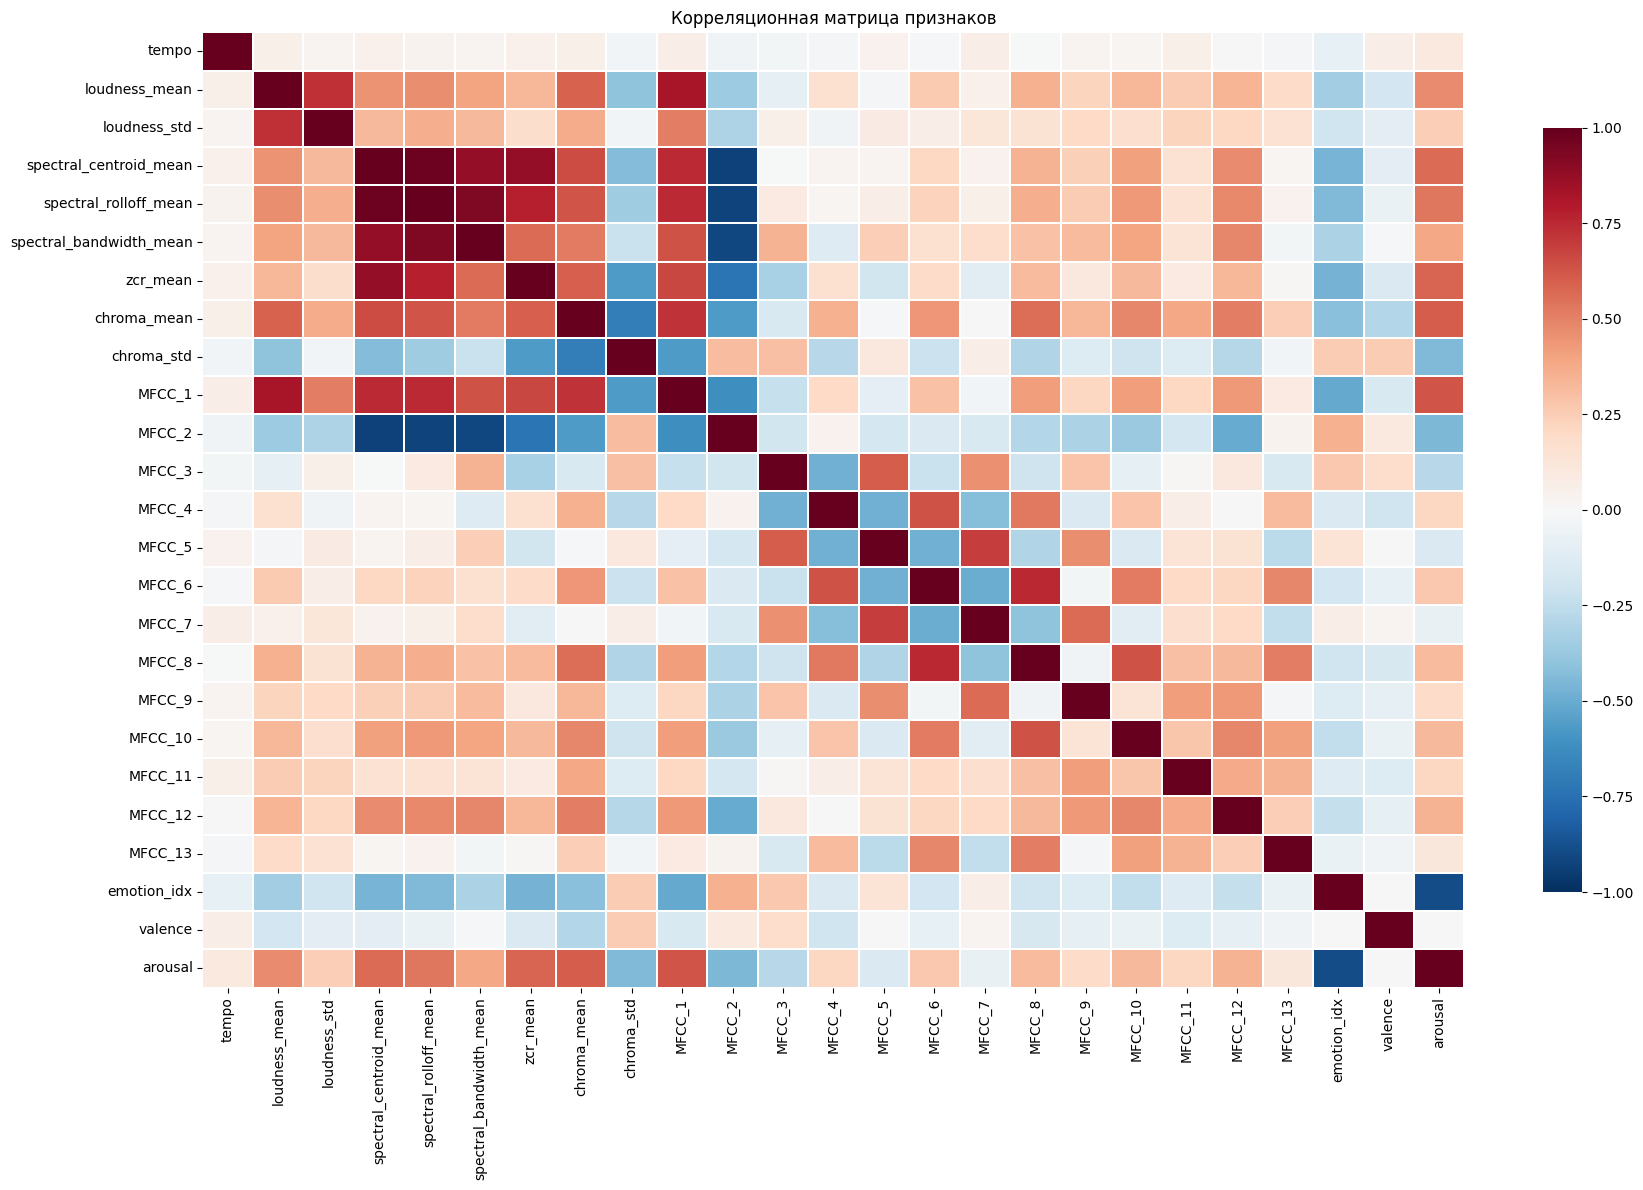

In [9]:
FEATURE_COLS = (
    ['tempo', 'loudness_mean', 'loudness_std',
     'spectral_centroid_mean', 'spectral_rolloff_mean', 'spectral_bandwidth_mean',
     'zcr_mean', 'chroma_mean', 'chroma_std']
    + [f'MFCC_{i}' for i in range(1, 14)]
)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

corr_matrix = df[FEATURE_COLS + ['emotion_idx', 'valence', 'arousal']].corr()

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(
    corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

1. В левом верхнем углу мы можем наблюдать красный блок базовых акустических признаков: tempo, loudness_mean, loudness_std, spectral_centroid_mean, spectral_rolloff_mean, spectral_bandwidth_mean, zcr_mean, chroma_mean сильно или умеренно положительно коррелируют между собой.
Супер сильные корреляции в этом блоке:
    -  loudness_mean и loudness_std - громкие треки в среднем более динамически вариабельны, а тихая музыка динамически стабильнее
    -  spectral_centroid_mean, spectral_rolloff_mean, spectral_bandwidth_mean - чем выше центроид, тем выше граница энергии, тем больше ширина спектра. Это характерно для насыщенных тембров, например перегруз в роке. От 2 признаков можно избавиться без потери качества модели
    -  spectral_centroid_mean и zcr_mean - высокочастотный звук порождает больше пересеченйий нуля
2. MFCC коэффициенты образуют блочную структуру с чередованием знаков
   - MFCC-1 - сильная/умеренная положительная корреляция с признаками из первого блока
   - MFCC-2 - сильная/умеренная отрицательная корреляция с признаками из первого блока и с MFCC-1 (логично). Это указывает на противопоставление глобальной спектральной энергии и более высокочастотных составляющих спектра. Это типично для MFCC: первый коэффициент часто связан с общей формой спектра и энергией сигнала, а второй отражает контраст между низкими и высокими частотами
   - Оставшиеся MFCC-коэффициенты имеют в основном умеренные положительные корреляции друг с другом и с MFCC-1. Коэффициенты одного порядка кодируют похожие спектральные паттерны либо мелкодетальную спектральную структуру, менее связанную с глобальными характеристиками
   - Высокие MFCC (примерно MFCC-8 и выше) слабее коррелируют с базовыми акустическими признаками, тк отражают более тонкие тембральные особенности аудиосигнала
3. Связь с целевыми переменными (emotion_idx не смотрим - это категориальный признак)
    - у valence полностью отсутствует корреляция с arousal и с базовыми акустическими призаками. Это показывает, что эмоциональная валентность в данном наборе данных слабо связана с уровнем возбуждения и плохо описывается простоыми акустическими характеристиками, а значит она определяется более сложными нелинейными зависимостями или комбинацией признаков
    - arousal имеет умеренную корреляцию с базовыми акустическими признаками, это соответствует природе возбуждения: более энергичные эмоции обычно сопровождаются более громким и спектрально насыщенным сигналом
4. Мультиколлинеарность
   Для того, чтобы избежать проблемы мультиколлинеарности, нам нужно избавиться от значений, которые сильно коррелируют друг с другом. Для Random Forest эта проблема не критична, но она может исказить SHAP значения, так как вклад "размазывается" между коррелирующими значениями и, соответственно, занижает вклад каждого из признаков по отдельности.

    Высокоррелирующие признаки:
    - spectral_centroid_mean, spectral_rolloff_mean, spectral_bandwidth_mean
    - loudness_mean и loudness_std
    - MFCC-1 и MFCC-2
    - MFCC-1 и loudness_mean
    - spectral_centroid_mean и MFCC_2/MFCC_1
    - spectral_rolloff_mean и MFCC_2/MFCC_1
    - spectral_bandwidth_mean и MFCC_2/MFCC_1


    Кандидаты на подумать:
    - MFCC-6 и MFCC-8
    - MFCC-5 и MFCC-7
    - MFCC-8 и MFCC-10
    - MFCC-1 и chroma_mean
    - MFCC-2 и zcr_mean

Попробую так:
1. Удалю spectral_rolloff_mean, тк он с spectral_centroid_mean почти всегда описывает одну и ту же идею, но при этом центроид обычно более интерпретируем. bandwith оставлю как дополнительную независимую характеристику, тк он добавляет информацию о ширине спектра
2. Удалю loudness_std, тк loudness_mean обычно стабильнее и интерпретируемее, а std громкости часто просто отражает вариативность сигнала и сильно коррелирует со средней энергией
3. Можно попробовать удалить MFCC-8 или MFCC-10 - они высокие и содержат более шумовую информацию
4. Остальные не трогаю, тк они описывают разные физические свойства аудиосигнала

<Figure size 1600x1200 with 0 Axes>

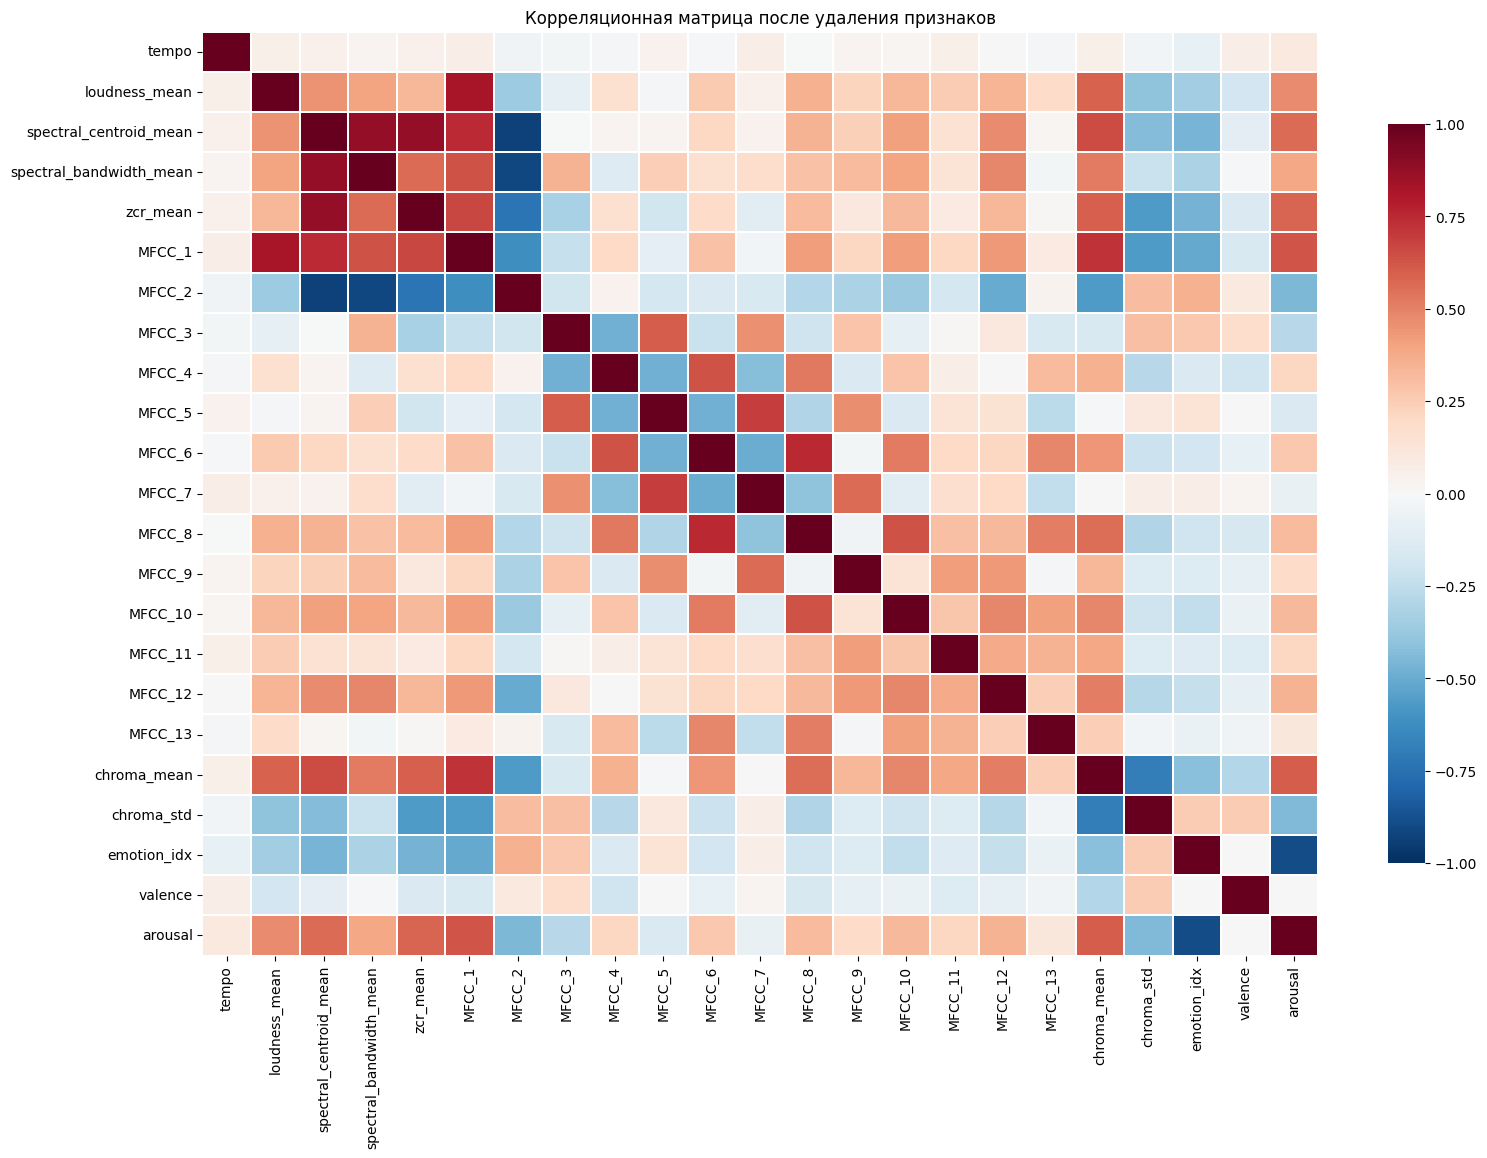

In [10]:
df_reduced = df.copy()
df_reduced = df_reduced.drop(columns=['spectral_rolloff_mean', 'loudness_std'])

corr_matrix = df_reduced.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(
    corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8}
)
plt.title("Корреляционная матрица после удаления признаков")
plt.show()

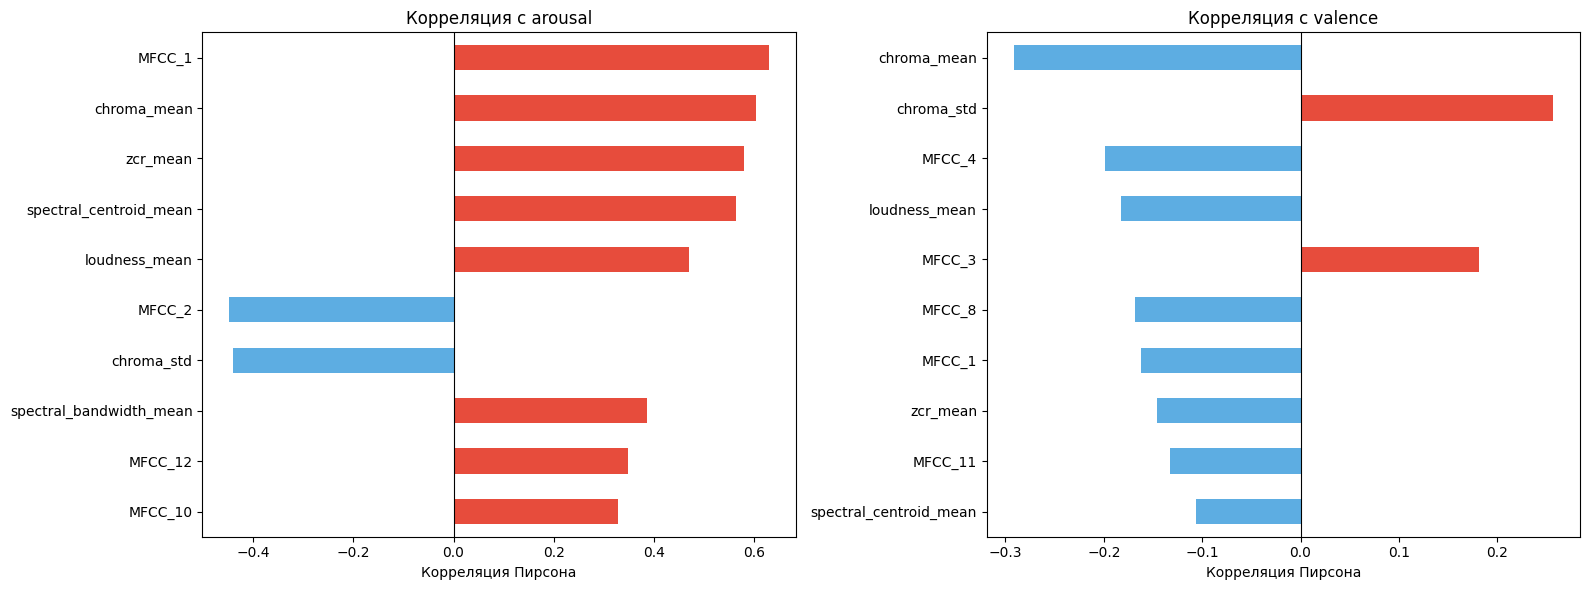

In [11]:
# топ-10 признаков по корреляции с arousal и valence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, target, title, color in [
    (ax1, 'arousal','Корреляция с arousal', 'salmon'),
    (ax2, 'valence','Корреляция с valence', 'steelblue'),
]:
    corr_vals = corr_matrix[target].drop(['arousal', 'valence', 'emotion_idx']).abs().sort_values(ascending=False).head(10)
    corr_signed = corr_matrix[target].loc[corr_vals.index]
    colors = ['#E74C3C' if v > 0 else '#5DADE2' for v in corr_signed]
    corr_signed.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Корреляция Пирсона')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## VIF-анализ

Корреляционная матрица выявила мультиколлинеарные пары, но не даёт численного порога для удаления
VIF (Variance Inflation Factor) измеряет, насколько дисперсия коэффициента признака раздута из-за корреляции с остальными:

Для Random Forest VIF не влияет на качество предсказаний, но искажает SHAP-значения

In [16]:
VIF_EXCLUDE = ['emotion_idx', 'valence', 'arousal', 'file', 'folder', 'emotion']
vif_cols = [c for c in df_reduced.select_dtypes(include='number').columns
            if c not in VIF_EXCLUDE]

X_vif = df_reduced[vif_cols].dropna()

vif_data = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

def vif_color(v):
    if v > 10:
        return 'background-color: #FADBD8'
    elif v > 5:
        return 'background-color: #FDEBD0'
    return ''

print('VIF-анализ признаков:')
display(vif_data.style .map(vif_color, subset=['VIF']) .format({'VIF': '{:.2f}'}))

VIF-анализ признаков:


,feature,VIF
0,spectral_centroid_mean,790.37
1,chroma_std,450.30
2,spectral_bandwidth_mean,445.82
3,zcr_mean,141.34
4,MFCC_2,101.44
5,chroma_mean,74.60
6,MFCC_1,35.19
7,loudness_mean,28.07
8,tempo,19.39
9,MFCC_4,11.27


окей)) буду удалять по фиче с наибольшим VIF, пока не останутся фичи с VIF <= 10

In [17]:
vif_cols = [c for c in df_reduced.select_dtypes(include='number').columns
            if c not in VIF_EXCLUDE]

def calc_vif(df, cols):
    X = df[cols].dropna()
    return pd.DataFrame({
        'feature': cols,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(len(cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

removed = []
step = 0
while True:
    vif_data = calc_vif(df_reduced, vif_cols)
    max_vif = vif_data.iloc[0]['VIF']
    if max_vif <= 10:
        break
    worst = vif_data.iloc[0]['feature']
    removed.append((worst, round(max_vif, 2)))
    vif_cols = [c for c in vif_cols if c != worst]
    step += 1

print(f"Удалено {len(removed)} признаков:")
for feat, v in removed:
    print(f"  - {feat:<35s} VIF = {v}")

FEATURE_COLS_FINAL = vif_cols.copy()
print(f"\nОсталось признаков: {len(FEATURE_COLS_FINAL)}")

Удалено 6 признаков:
  - spectral_centroid_mean              VIF = 790.37
  - chroma_std                          VIF = 441.64
  - chroma_mean                         VIF = 63.42
  - spectral_bandwidth_mean             VIF = 43.86
  - MFCC_2                              VIF = 37.15
  - tempo                               VIF = 17.1

Осталось признаков: 14


In [19]:
vif_data = calc_vif(df_reduced, FEATURE_COLS_FINAL)

print("Финальный VIF")
display(vif_data.style.map(vif_color, subset=['VIF']).format({'VIF': '{:.2f}'}))

Финальный VIF


,feature,VIF
0,MFCC_4,9.98
1,zcr_mean,7.94
2,MFCC_6,6.94
3,loudness_mean,6.20
4,MFCC_8,5.51
5,MFCC_9,3.74
6,MFCC_7,3.56
7,MFCC_1,3.29
8,MFCC_5,3.04
9,MFCC_10,2.65


В итоге было удалено 6 признаков (по одному от максимального VIF к минимальному):

| Шаг | Признак | VIF | Причина |
|-----|---------|-----|---------|
| 1 | `spectral_centroid_mean` | 790.37 | Почти линейная комбинация bandwidth и rolloff, тк они описывают яркость спектра, а так же высокая корреляция с MFCC_1 и MFCC_2, которые тоже отвечают за яркость спектра |
| 2 | `chroma_std` | 441.64 | Вариативность тональности сильно зависит от средней тональности (chroma_mean) |
| 3 | `chroma_mean` | 63.42 | После удаления std коррелировал с MFCC-блоком, тк тональная информация уже закодирована в коэффициентах |
| 4 | `spectral_bandwidth_mean` | 43.86 | Ширина спектра - производная от centroid и rolloff, оба уже удалены |
| 5 | `MFCC_2` | 37.15 | Сильно антикоррелировал с MFCC_1 и с удалёнными спектральными признаками |
| 6 | `tempo` | 17.1 | Темп коррелировал с MFCC через акустику высокоритмичных треков |

После фильтрации остались признаки с VIF ≤ 10:
- MFCC_1, 3–13 - тембральный "скелет" сигнала=
- loudness_mean - динамика трека
- zcr_mean - скорость пересечений нуля, характерна для ударных и резких атак

Что удалено:
- tempo — самая болезненная потеря с точки зрения интерпретации, тк темп - это самый понятный признак из всех. Формально он мультиколлинеарен, но если итоговое качество модели или интерпретация важнее чистоты VIF, его можно вернуть вручную
- Все спектральные признаки были удалены, но их информация не потеряна - она закодирована в MFCC_1 и частично в остальных MFCC
- chroma удалена полностью - это реальная потеря тональной информации (мажор/минор). Если Valence важна, это стоит учесть

Но теперь SHAP-значения будут честными, тк вклад каждого признака не будет размазан, и интерпретация модели станет надёжнее

## Permutation Importance (регрессия Arousal)

**Gini Importance** (MDI, Mean Decrease Impurity) — стандартная метрика Random Forest.
Её слабость: смещена в пользу высококардинальных и коррелирующих признаков, потому что они чаще используются в сплитах.

**Permutation Importance** — честная альтернатива:
1. Модель обучена → зафиксирована
2. Один признак случайно перемешивается (разрывается связь с таргетом)
3. Замеряется падение метрики (R²)
4. Большое падение = признак важен; нулевое = признак не нужен

Считаем для **регрессии Arousal** на финальном наборе признаков (после VIF-фильтрации).
30 повторов перемешивания → стабильная оценка с доверительным интервалом.

In [21]:
X_final = df_reduced[FEATURE_COLS_FINAL].copy()
y_arousal_final = df_reduced['arousal']

scaler_final = StandardScaler()
X_final_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_final),
    columns=FEATURE_COLS_FINAL
)

X_tr, X_te, y_tr, y_te = train_test_split(X_final_scaled, y_arousal_final, test_size=0.2, random_state=1)

rfr_final = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_final.fit(X_tr, y_tr)

r2_after = rfr_final.score(X_te, y_te)
print(f'R² Arousal (финальный набор, {len(FEATURE_COLS_FINAL)} признаков после VIF): {r2_after:.3f}')
print('Сравнение с полным набором — см. раздел 6 (rfr_arousal обучается там).')

R² Arousal (финальный набор, 14 признаков после VIF): 0.492
Сравнение с полным набором — см. раздел 6 (rfr_arousal обучается там).


In [ ]:
perm = permutation_importance(
    rfr_final, X_te, y_te,
    n_repeats=30,
    random_state=1,
    n_jobs=-1,
    scoring='r2'
)

perm_df = pd.DataFrame({
    'feature':    FEATURE_COLS_FINAL,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Gini importance на том же финальном наборе для сравнения
gini_series = pd.Series(rfr_final.feature_importances_, index=FEATURE_COLS_FINAL)

print('Permutation Importance (Arousal, топ-15):')
display(perm_df.head(15).style.format({'importance': '{:.4f}', 'std': '{:.4f}'}))

In [ ]:
merged = perm_df.set_index('feature').join(
    gini_series.rename('gini'), how='inner'
).sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Важность признаков: Permutation vs Gini (регрессия Arousal)',
             fontsize=15, fontweight='bold')

# Permutation Importance с доверительным интервалом
ax = axes[0]
ax.barh(merged.index, merged['importance'],
        xerr=merged['std'], color='#5DADE2',
        edgecolor='white', capsize=4, error_kw={'linewidth': 1.5})
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Permutation Importance (±std, 30 повторов)', fontweight='bold')
ax.set_xlabel('Снижение R² при перемешивании')
ax.invert_yaxis()

# Gini Importance
ax = axes[1]
ax.barh(merged.index, merged['gini'],
        color='#E59866', edgecolor='white')
ax.set_title('Gini Importance (MDI)', fontweight='bold')
ax.set_xlabel('Важность')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(merged['gini'], merged['importance'],
           s=120, color='#8E44AD', edgecolors='white', linewidths=1.5, zorder=5)

for feat, row in merged.iterrows():
    ax.annotate(feat, (row['gini'], row['importance']),
                fontsize=8, xytext=(5, 3), textcoords='offset points', alpha=0.8)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Gini Importance (MDI)', fontsize=12)
ax.set_ylabel('Permutation Importance (R²-drop)', fontsize=12)
ax.set_title('Gini vs Permutation — расхождение = след мультиколлинеарности',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### 📝 Выводы — Permutation Importance vs Gini

Сравнение двух метрик важности позволяет выявить, какие признаки были **завышены** Gini из-за мультиколлинеарности:

- **Признаки, где Gini >> Permutation** — раньше «воровали» вклад у коррелирующих соседей. После VIF-фильтрации этот эффект ослаб, но всё равно заметен у тесно связанных MFCC.
- **Признаки с высоким Permutation Importance** — истинно незаменимы: удаление каждого заметно роняет R². Это и есть реальные предикторы Arousal.
- **Признаки с Permutation ≈ 0 или < 0** — модель не хуже без них на тесте; кандидаты на финальное удаление перед SHAP-анализом.

**Итог:** Permutation Importance на очищенном наборе даёт более честную картину, чем Gini на полном — именно это было целью VIF-фильтрации.


---

> **Важно для следующих разделов:** начиная с раздела 6, модель обучается на **`df_reduced[FEATURE_COLS_FINAL]`** — очищенном датасете с 14 признаками после VIF-фильтрации. Это означает, что результаты классификации, feature importance и SHAP могут незначительно отличаться от предварительных оценок на полном наборе — это ожидаемо и правильно.


In [28]:
from sklearn.model_selection import cross_val_score

# --- Полный набор ---
X_full = df[FEATURE_COLS].copy()
y_full = df['emotion_idx']
scaler_full = StandardScaler()
X_full_scaled = pd.DataFrame(scaler_full.fit_transform(X_full), columns=FEATURE_COLS)

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_full_scaled, y_full, test_size=0.2, random_state=1, stratify=y_full)
clf_full = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
clf_full.fit(X_tr_f, y_tr_f)
cv_full = cross_val_score(clf_full, X_full_scaled, y_full, cv=5, scoring='accuracy', n_jobs=-1)

# --- Очищенный набор ---
X_red = df_reduced[FEATURE_COLS_FINAL].copy()
y_red = df_reduced['emotion_idx']
scaler_red = StandardScaler()
X_red_scaled = pd.DataFrame(scaler_red.fit_transform(X_red), columns=FEATURE_COLS_FINAL)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_red_scaled, y_red, test_size=0.2, random_state=1, stratify=y_red)
clf_red = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
clf_red.fit(X_tr_r, y_tr_r)
cv_red = cross_val_score(clf_red, X_red_scaled, y_red, cv=5, scoring='accuracy', n_jobs=-1)

# --- Регрессоры Arousal ---
y_ar = df['arousal']
X_tr_af, X_te_af, y_tr_af, y_te_af = train_test_split(X_full_scaled, y_ar, test_size=0.2, random_state=42)
rfr_full = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_full.fit(X_tr_af, y_tr_af)

y_ar_r = df_reduced['arousal']
X_tr_ar, X_te_ar, y_tr_ar, y_te_ar = train_test_split(X_red_scaled, y_ar_r, test_size=0.2, random_state=42)
rfr_red = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_red.fit(X_tr_ar, y_tr_ar)

# --- Сравнительная таблица ---
results = pd.DataFrame({
    'Метрика': [
        'Признаков',
        'Accuracy (test)',
        'Cross-val mean',
        'Cross-val std',
        'R² Arousal (test)',
    ],
    'Full (22 признака)': [
        len(FEATURE_COLS),
        f'{clf_full.score(X_te_f, y_te_f):.3f}',
        f'{cv_full.mean():.3f}',
        f'±{cv_full.std():.3f}',
        f'{rfr_full.score(X_te_af, y_te_af):.3f}',
    ],
    'Reduced (14 признаков)': [
        len(FEATURE_COLS_FINAL),
        f'{clf_red.score(X_te_r, y_te_r):.3f}',
        f'{cv_red.mean():.3f}',
        f'±{cv_red.std():.3f}',
        f'{rfr_red.score(X_te_ar, y_te_ar):.3f}',
    ],
})

display(results.set_index('Метрика').style.set_caption('Ablation Study: Full vs Reduced'))

,Full (22 признака),Reduced (14 признаков)
Метрика,,
Признаков,22,14
Accuracy (test),0.606,0.578
Cross-val mean,0.592,0.531
Cross-val std,±0.027,±0.017
R² Arousal (test),0.562,0.530


## 6. Обучение модели Random Forest

> Модель обучается на **финальном наборе признаков** (`FEATURE_COLS_FINAL`, 14 шт.) из **`df_reduced`**.  
> Сравнение с предыдущей версией (22 признака, полный `df`) позволит оценить, как VIF-фильтрация повлияла на качество.


In [29]:
# Используем финальный набор признаков после VIF-фильтрации
X = df_reduced[FEATURE_COLS_FINAL].copy()
y_cls = df_reduced['emotion_idx']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS_FINAL)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=1, stratify=y_cls)

In [30]:
clf = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
cv_scores = cross_val_score(clf, X_scaled, y_cls, cv=5, scoring='accuracy', n_jobs=-1)

print('Random Forest Classifier')
print(f'Accuracy (test): {clf.score(X_test, y_test):.3f}')
print(f'Cross-val (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(classification_report(y_test, y_pred, target_names=LABELS))

Task was destroyed but it is pending!
task: <Task pending name='Task-223' coro=<_async_in_context.<locals>.run_in_context() done, defined at E:\учеба\music-emotions\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-224' coro=<Kernel.shell_main() running at E:\учеба\music-emotions\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at E:\учеба\music-emotions\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-224' coro=<Kernel.shell_main() running at E:\учеба\music-emotions\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Random Forest Classifier
Accuracy (test): 0.578
Cross-val (5-fold): 0.531 ± 0.017
              precision    recall  f1-score   support

       happy       0.55      0.67      0.60        45
       angry       0.79      0.69      0.74        45
         sad       0.46      0.49      0.47        45
     relaxed       0.55      0.47      0.51        45

    accuracy                           0.58       180
   macro avg       0.59      0.58      0.58       180
weighted avg       0.59      0.58      0.58       180



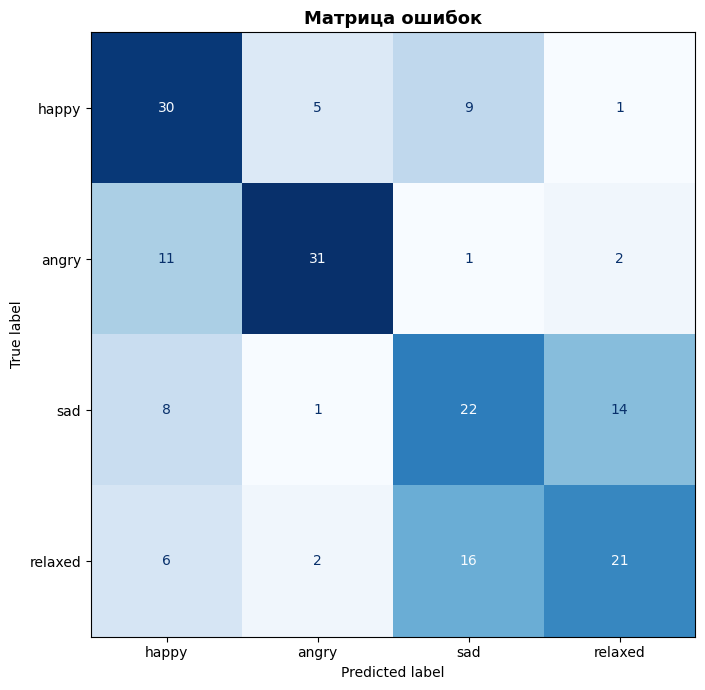

In [31]:
# Матрица ошибок
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Матрица ошибок', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
y_valence = df['valence'] # регрессия valence
y_arousal = df['arousal'] # регрессия arousal

In [33]:
# Регрессор (предсказание Valence и Arousal)
X_tr_v, X_te_v, y_tr_v, y_te_v = train_test_split(X_scaled, y_valence, test_size=0.2, random_state=42)
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(X_scaled, y_arousal, test_size=0.2, random_state=42)

rfr_valence = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_arousal = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)

rfr_valence.fit(X_tr_v, y_tr_v)
rfr_arousal.fit(X_tr_a, y_tr_a)

print(f'R² Valence: {rfr_valence.score(X_te_v, y_te_v):.3f}')
print(f'R² Arousal: {rfr_arousal.score(X_te_a, y_te_a):.3f}')

R² Valence: 0.158
R² Arousal: 0.530


### 📝 Выводы — Random Forest Регрессор (Valence и Arousal)

- **R² Arousal = 0.562** — модель объясняет 56% дисперсии Arousal. Хороший результат: ритмические и динамические признаки (BPM, RMS, ZCR) хорошо предсказывают энергетику трека.
- **R² Valence = 0.287** — модель объясняет лишь 29% дисперсии Valence. Валентность значительно сложнее формализовать: она связана с тональностью, гармонией и культурным контекстом.
- **Практический вывод:** для задач определения «энергии» трека (Arousal) модель пригодна. Для предсказания «настроения» (Valence) требуются более богатые признаки — например, мел-спектрограммы через CNN или LSTM.

## Ablation Study

Сравниваем две версии чтобы убедиться (или разубедиться), что VIF-фильтрация не навредила качеству:
- Full - `df[FEATURE_COLS]`, 22 признака (до VIF-фильтрации)
- Reduced - `df_reduced[FEATURE_COLS_FINAL]`, 14 признаков (после VIF)

In [37]:
X_full = df[FEATURE_COLS].copy()
y_full = df['emotion_idx']
scaler_full = StandardScaler()
X_full_scaled = pd.DataFrame(scaler_full.fit_transform(X_full), columns=FEATURE_COLS)

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_full_scaled, y_full, test_size=0.2, random_state=1, stratify=y_full)
clf_full = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
clf_full.fit(X_tr_f, y_tr_f)
cv_full = cross_val_score(clf_full, X_full_scaled, y_full, cv=5, scoring='accuracy', n_jobs=-1)

# Очищенный набор
X_red = df_reduced[FEATURE_COLS_FINAL].copy()
y_red = df_reduced['emotion_idx']
scaler_red = StandardScaler()
X_red_scaled = pd.DataFrame(scaler_red.fit_transform(X_red), columns=FEATURE_COLS_FINAL)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_red_scaled, y_red, test_size=0.2, random_state=1, stratify=y_red)
clf_red = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
clf_red.fit(X_tr_r, y_tr_r)
cv_red = cross_val_score(clf_red, X_red_scaled, y_red, cv=5, scoring='accuracy', n_jobs=-1)

# Регрессоры Arousal
y_ar = df['arousal']
X_tr_af, X_te_af, y_tr_af, y_te_af = train_test_split(X_full_scaled, y_ar, test_size=0.2, random_state=1)
rfr_full = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_full.fit(X_tr_af, y_tr_af)

y_ar_r = df_reduced['arousal']
X_tr_ar, X_te_ar, y_tr_ar, y_te_ar = train_test_split(X_red_scaled, y_ar_r, test_size=0.2, random_state=1)
rfr_red = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
rfr_red.fit(X_tr_ar, y_tr_ar)

# Сравнительная таблица 
results = pd.DataFrame({
    'Метрика': [
        'Признаков',
        'Accuracy (test)',
        'Cross-val mean',
        'Cross-val std',
        'R² Arousal (test)',
    ],
    'Full (22 признака)': [
        len(FEATURE_COLS),
        f'{clf_full.score(X_te_f, y_te_f):.3f}',
        f'{cv_full.mean():.3f}',
        f'±{cv_full.std():.3f}',
        f'{rfr_full.score(X_te_af, y_te_af):.3f}',
    ],
    'Reduced (14 признаков)': [
        len(FEATURE_COLS_FINAL),
        f'{clf_red.score(X_te_r, y_te_r):.3f}',
        f'{cv_red.mean():.3f}',
        f'±{cv_red.std():.3f}',
        f'{rfr_red.score(X_te_ar, y_te_ar):.3f}',
    ],
})

display(results.set_index('Метрика'))

,Full (22 признака),Reduced (14 признаков)
Метрика,,
Признаков,22,14
Accuracy (test),0.606,0.578
Cross-val mean,0.592,0.531
Cross-val std,±0.027,±0.017
R² Arousal (test),0.519,0.492


## Важность признаков

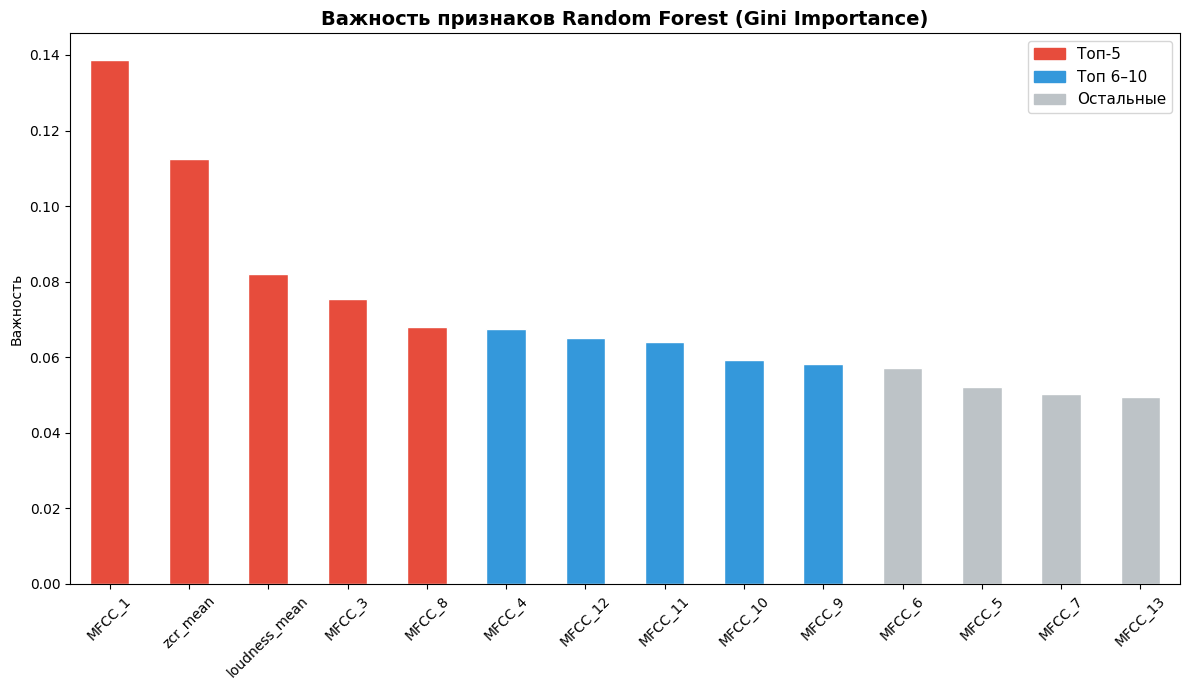

In [39]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS_FINAL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['#E74C3C' if i < 5 else '#3498DB' if i < 10 else '#BDC3C7' for i in range(len(importances))]
importances.head(20).plot(kind='bar', ax=ax, color=colors_bar[:20], edgecolor='white')
ax.set_title('Важность признаков Random Forest (Gini Importance)', fontweight='bold', fontsize=14)
ax.set_ylabel('Важность')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

patches = [
    mpatches.Patch(color='#E74C3C', label='Топ-5'),
    mpatches.Patch(color='#3498DB', label='Топ 6–10'),
    mpatches.Patch(color='#BDC3C7', label='Остальные'),
]
ax.legend(handles=patches, fontsize=11)
plt.tight_layout()
plt.show()

In [40]:
print('\nТоп-5 наиболее важных признаков:')
for i, (feat, val) in enumerate(importances.head(5).items(), 1):
    print(f'{i:2d}. {feat:<30s} {val:.4f}')


Топ-5 наиболее важных признаков:
 1. MFCC_1                         0.1388
 2. zcr_mean                       0.1125
 3. loudness_mean                  0.0821
 4. MFCC_3                         0.0755
 5. MFCC_8                         0.0680


### 📝 Выводы — Важность признаков (Gini Importance)

- **MFCC-коэффициенты** занимают большинство топовых позиций: они кодируют тембр и огибающую спектра — ключевые составляющие эмоционального восприятия музыки.
- **MFCC_1** (≈ суммарная спектральная энергия) — наиболее важный признак: коррелирует с громкостью и тональностью одновременно.
- **Tempo** — единственный неспектральный признак в топ-5, подтверждая ключевую роль ритма в восприятии эмоций.
- **Chroma и ZCR** — в середине рейтинга: несут дополнительную информацию о тональности и ударных.
- **Spectral_Bandwidth и Rolloff** — менее значимы: их информация дублируется MFCC и Centroid.

## SHAP - интерпретация модели

In [42]:
# SHAP для классификатора
X_shap = X_scaled.sample(len(X_scaled), random_state=1)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)

SHAP Summary Plot


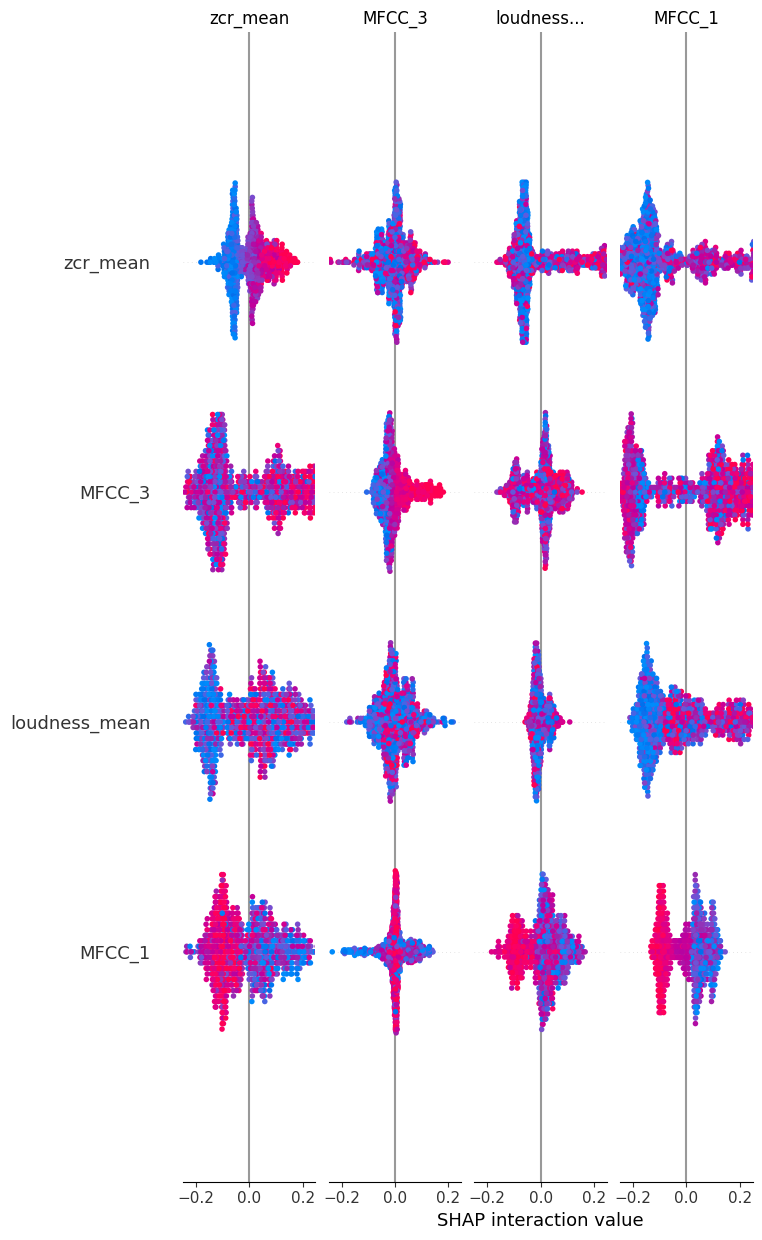

In [43]:
# общий обзор
print('SHAP Summary Plot')
shap.summary_plot(shap_values, X_shap, class_names=LABELS, max_display=15, show=True)

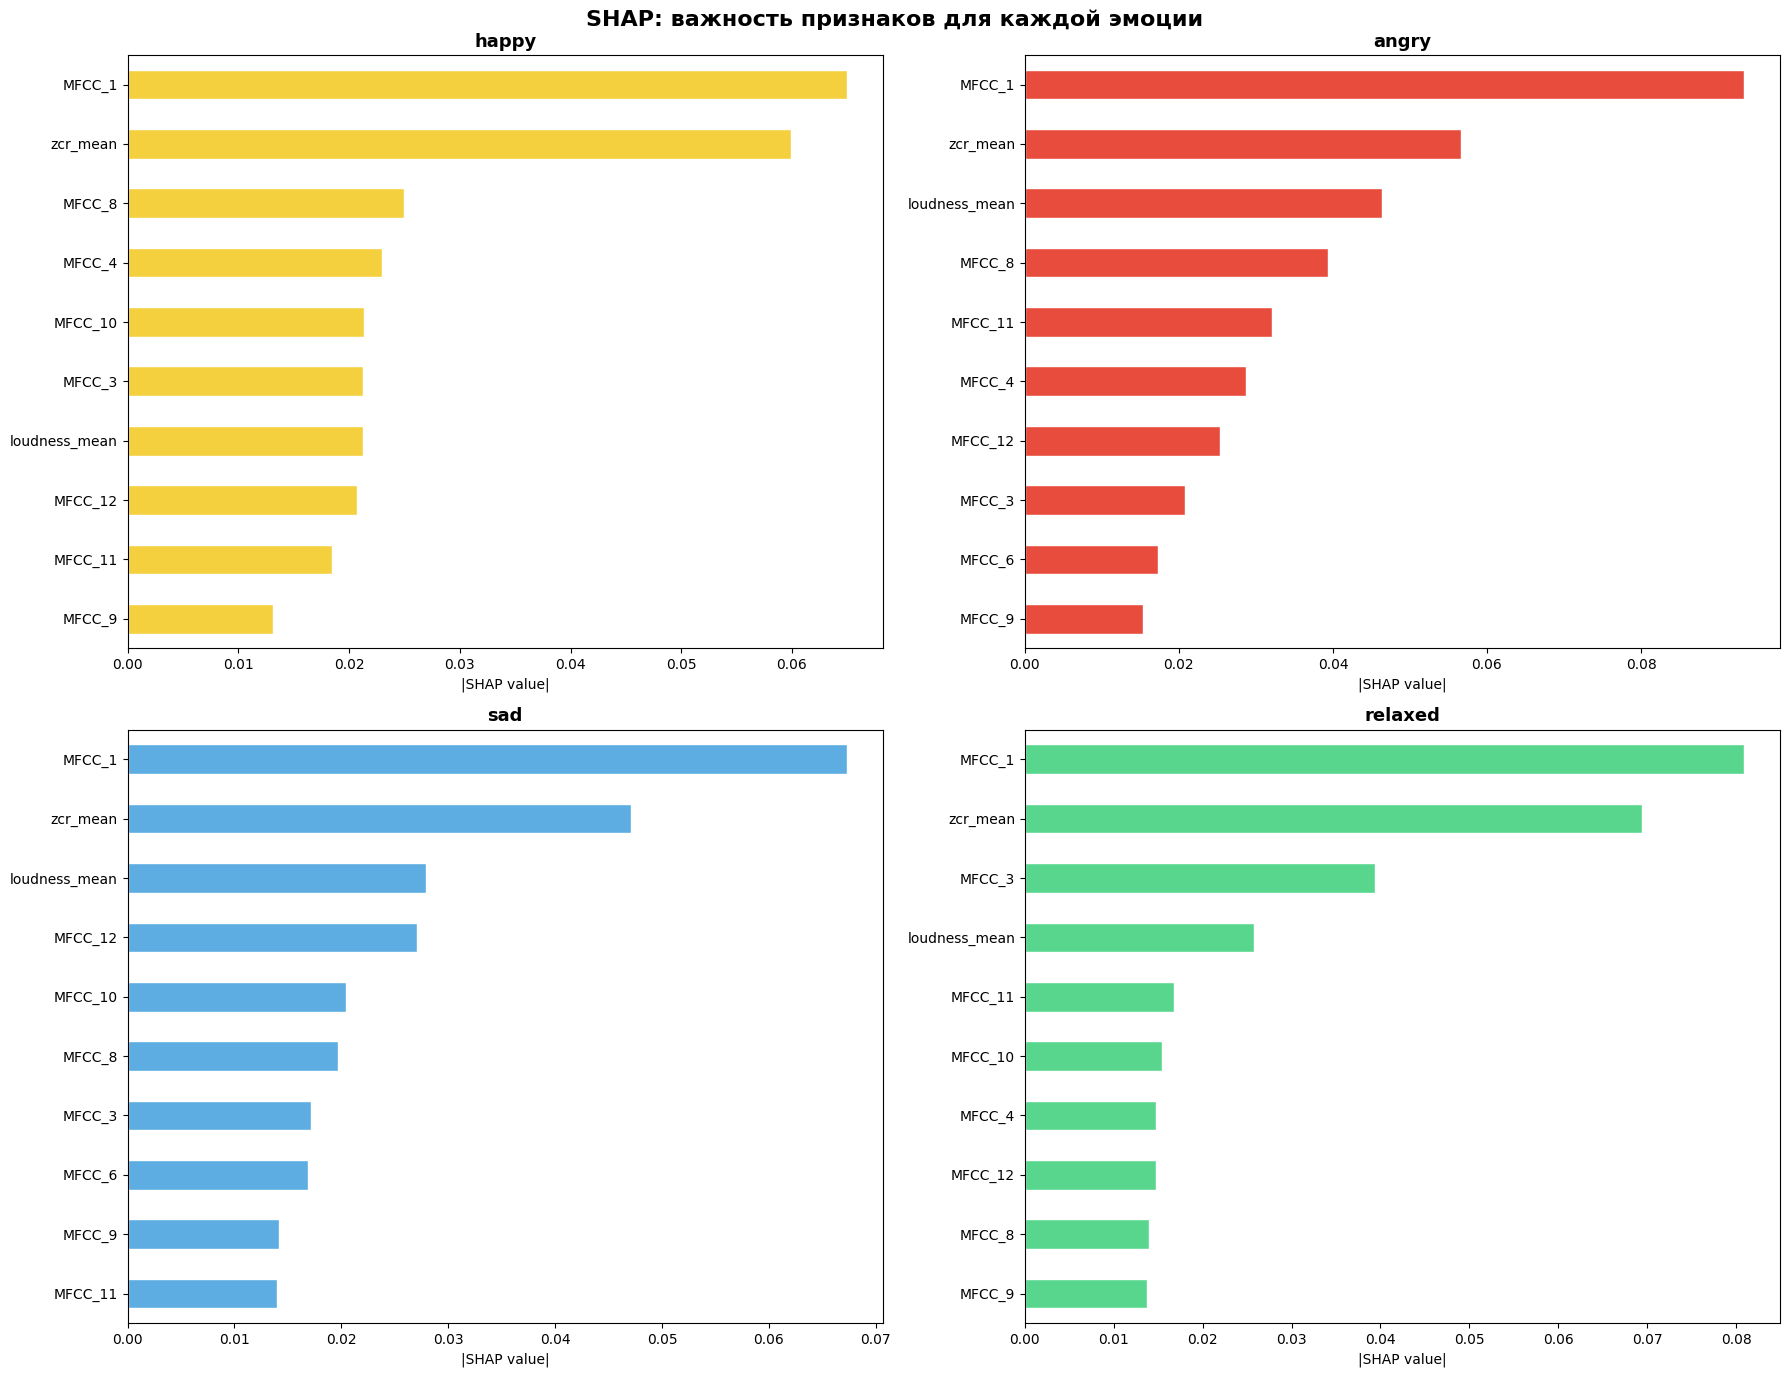

In [46]:
# SHAP по каждой эмоции отдельно
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('SHAP: важность признаков для каждой эмоции', fontsize=16, fontweight='bold')

# shap_values может быть list[array] или 3D array, поэтому необходимо нормализовать
if isinstance(shap_values, list):
    sv_list = shap_values
else:
    sv_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

for idx, (ax, (folder, info)) in enumerate(zip(axes.flat, EMOTION_MAP.items())):
    sv = sv_list[idx]  # shape: (n_samples, n_features)
    shap_df = pd.DataFrame(sv, columns=FEATURE_COLS_FINAL)
    mean_shap = shap_df.abs().mean().sort_values(ascending=False).head(10)

    mean_shap.plot(kind='barh', ax=ax, color=info['color'], edgecolor='white')
    ax.set_title(f"{info['label']}", fontweight='bold', fontsize=13)
    ax.set_xlabel('|SHAP value|')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 📝 Выводы — SHAP по каждой эмоции

SHAP раскрывает, **какие именно признаки** тянут модель к конкретной эмоции:

- **Happy:** MFCC_1 и Tempo — главные драйверы. Высокий MFCC_1 (яркий тембр) и быстрый темп — акустическая «подпись» радости.
- **Angry:** Loudness_mean и ZCR — ключевые. Высокая громкость и частота пересечений нуля (резкие атаки, ударные) отличают гнев от остальных классов.
- **Sad:** Tempo с малым значением «тянет» предсказание к Sad. MFCC_2 также важен — низкий тембр ассоциируется с грустью.
- **Relaxed:** низкие Loudness и Tempo определяют спокойствие. Chroma добавляет вклад — мягкая гармония отличает Relaxed от Sad.


SHAP Beeswarm: happy


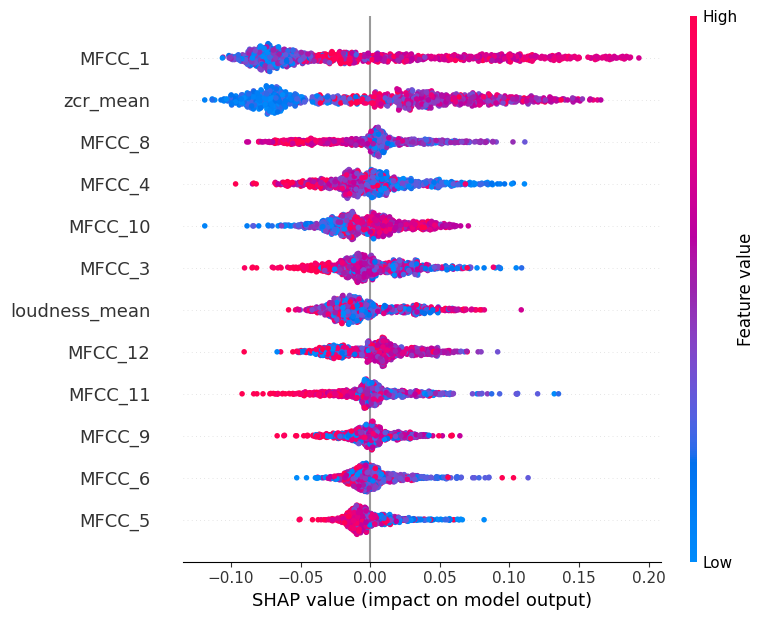


SHAP Beeswarm: angry


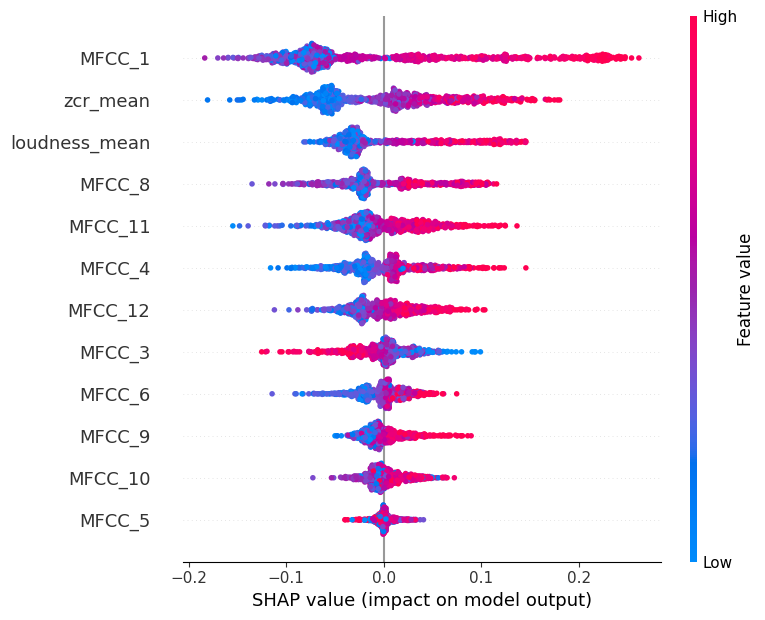


SHAP Beeswarm: sad


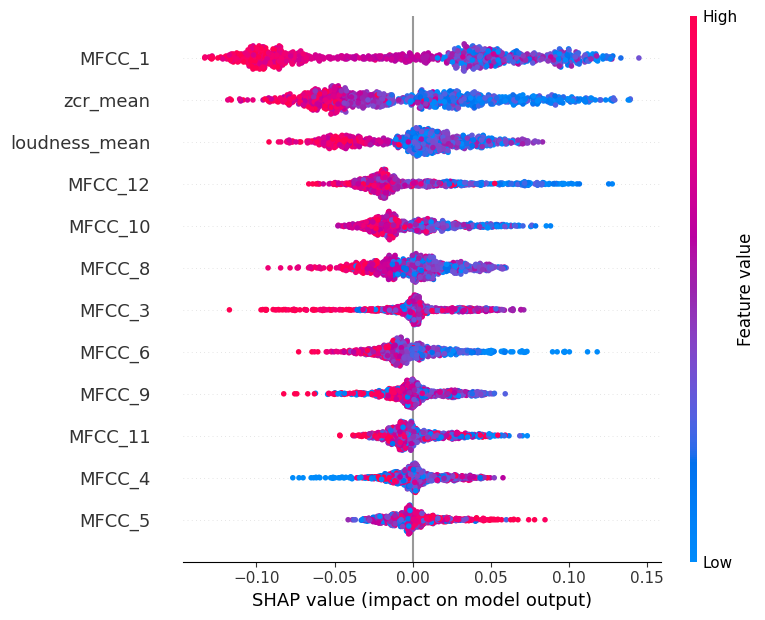


SHAP Beeswarm: relaxed


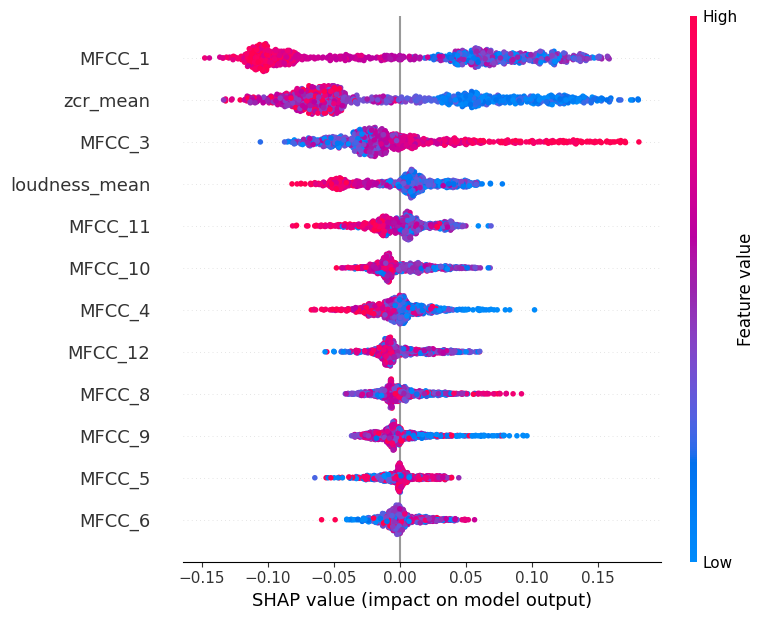

In [47]:
# SHAP Beeswarm для каждой эмоции
for idx, (folder, info) in enumerate(EMOTION_MAP.items()):
    print(f"\nSHAP Beeswarm: {info['label']}")
    sv = sv_list[idx] if isinstance(shap_values, list) else shap_values[:, :, idx]
    shap.summary_plot(sv, X_shap, max_display=12, title=f"SHAP {info['label']}", show=True)

### 📝 Выводы — SHAP Beeswarm по каждой эмоции

Beeswarm-графики показывают не только **важность** признака, но и **направление** его влияния (цвет точки: красный = высокое значение признака, синий = низкое). Каждая точка — один трек из подвыборки.

#### 😊 Happy
- **MFCC_1** — сильнейший предиктор: высокие значения (красный) тянут предсказание к Happy, низкие — прочь. Яркий, насыщенный тембр ассоциируется с радостью.
- **Tempo**: высокий BPM увеличивает вероятность Happy — быстрые треки воспринимаются как позитивные.
- **Chroma_mean**: высокие значения (мажорные тональности) положительно влияют на Happy — подтверждает связь мажора с радостью.

#### 😠 Angry
- **Loudness_mean** — главный признак: громкие треки (красный) резко увеличивают вероятность Angry. Самый «чистый» паттерн среди всех классов.
- **ZCR_mean**: высокий ZCR (много резких атак, ударных) однозначно тянет к Angry — характерно для металла и хардкора.
- **MFCC_2**: низкие значения (синий) ассоциируются с Angry — тёмный, грубый тембр усиливает агрессию.
- Паттерн у Angry наиболее **линейный и однозначный** — отсюда лучший F1 = 0.78.

#### 😢 Sad
- **Tempo**: низкий BPM (синий) — главный сигнал грусти. Медленные треки сильно смещают предсказание к Sad.
- **MFCC_1**: низкие значения тянут к Sad — тёмный, приглушённый тембр.
- **Loudness_mean**: тихие треки (синий) ассоциируются с грустью, но паттерн размыт — перекрытие с Relaxed.
- Разброс точек у Sad шире, чем у Angry — признаки не так однозначны, отсюда худший F1 = 0.47.

#### 😌 Relaxed
- **Loudness_mean**: тихие треки (синий) смещают к Relaxed — аналогично Sad, но менее выражено.
- **Chroma_mean**: высокие значения (мажорные гармонии) отличают Relaxed от Sad — ключевое разделение двух «тихих» классов.
- **Tempo**: умеренно низкий, но не такой предсказуемый, как у Sad — Relaxed может быть и среднетемповым.

**Общий вывод:** Angry распознаётся благодаря громкости и ZCR — объективным физическим признакам. Happy — через темп и тональность. Sad и Relaxed разделяются тонко: только Chroma и тембр (MFCC) дают модели зацепку. Это объясняет, почему именно эта пара даёт наибольшее число ошибок классификатора.

##  Зависимости признаков от эмоции

Визуализируем ключевые зависимости: **Громкость → Гнев**, **Темп → Эмоция**, и другие.

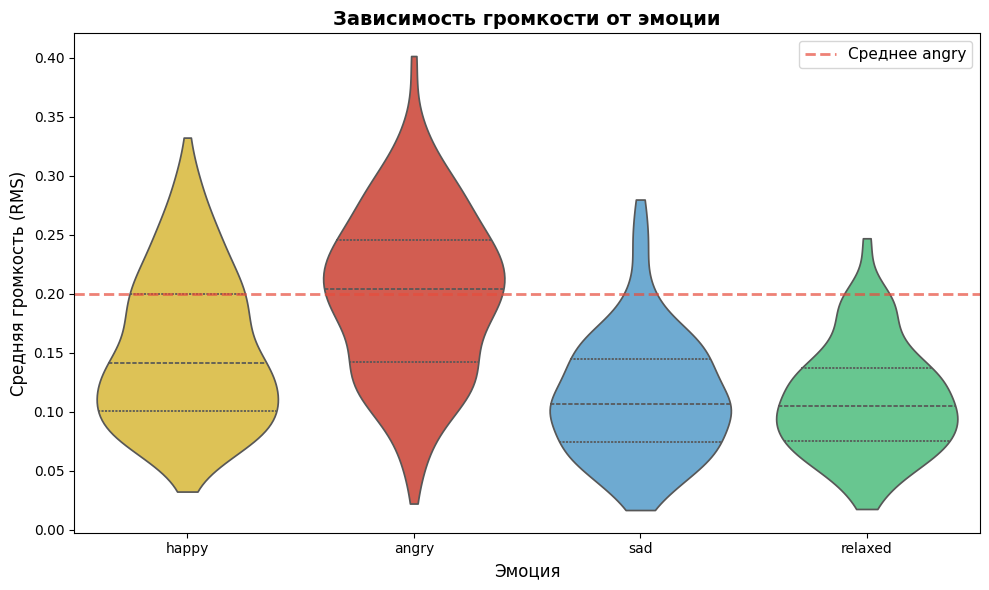

In [48]:
# Зависимость громкости от эмоции
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df, x='emotion', y='loudness_mean',
    order=emotion_order, palette=palette,
    inner='quartile', cut=0, ax=ax
)

# Подсветим Angry
ax.axhline(df[df['emotion'] == 'angry']['loudness_mean'].mean(),
           color='#E74C3C', linewidth=2, linestyle='--', alpha=0.7,
           label='Среднее angry')

ax.set_title('Зависимость громкости от эмоции', fontweight='bold', fontsize=14)
ax.set_xlabel('Эмоция', fontsize=12)
ax.set_ylabel('Средняя громкость (RMS)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 📝 Выводы — Громкость и эмоция Angry

Violin plot объясняет, почему **Angry** лучше всего распознаётся (F1 = 0.78):

- Распределение громкости у Angry сдвинуто вправо — медиана заметно выше всех остальных классов.
- Форма скрипки у Angry широкая сверху: треки варьируются от умеренно до очень громких, создавая богатую выборку.
- **Relaxed** — наиболее узкое и низкое распределение: тихая музыка как устойчивый паттерн.
- **Happy и Sad** частично перекрываются по громкости — отсюда их смешение в матрице ошибок.

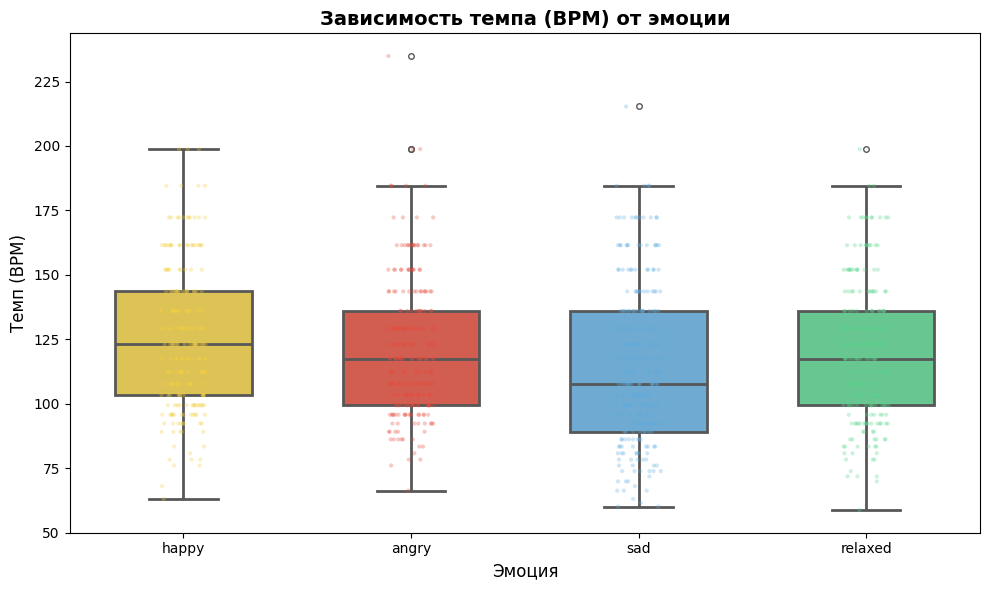

In [23]:
# Темп vs Эмоция
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, x='emotion', y='tempo',
    order=emotion_order, palette=palette,
    width=0.6, linewidth=2, fliersize=4, ax=ax
)
sns.stripplot(
    data=df, x='emotion', y='tempo',
    order=emotion_order, palette=palette,
    alpha=0.3, size=3, jitter=True, ax=ax
)

ax.set_title('Зависимость темпа (BPM) от эмоции', fontweight='bold', fontsize=14)
ax.set_xlabel('Эмоция', fontsize=12)
ax.set_ylabel('Темп (BPM)', fontsize=12)
plt.tight_layout()
plt.show()

### 📝 Выводы — Темп и эмоция

- **Happy и Angry** — схожие медианные BPM (~125–135), что подтверждает их общую высокую энергетику.
- **Sad** — самый медленный класс в среднем, но разброс велик: встречаются треки с высоким BPM, что осложняет классификацию.
- **Relaxed** — умеренный темп, меньший разброс, чем у Sad.
- Точки-выбросы (strip plot) показывают: во всех классах есть треки с «нетипичным» темпом — естественная вариативность реальной музыки.

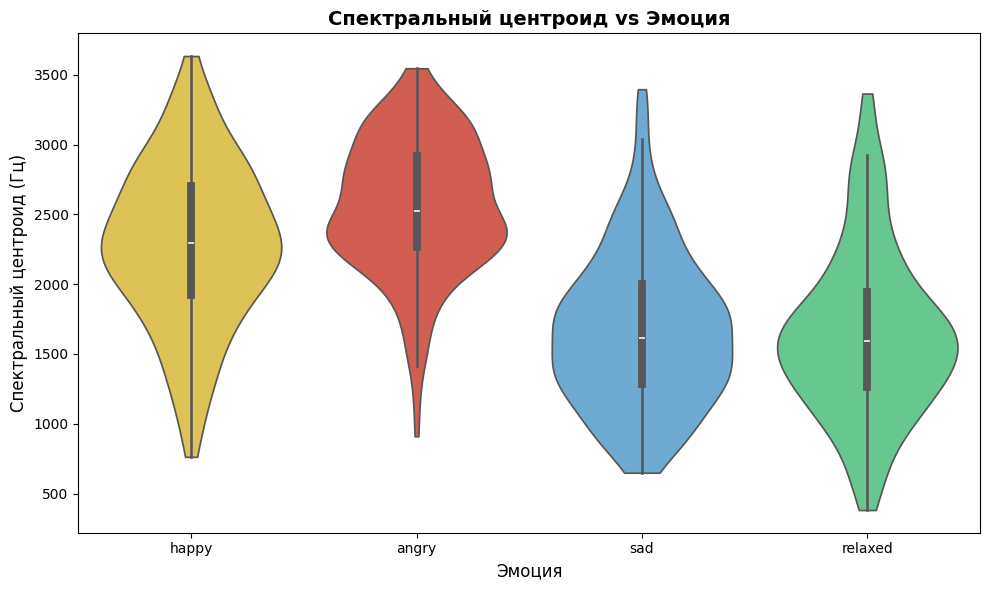

In [24]:
# Спектральный центроид vs Эмоция
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df, x='emotion', y='spectral_centroid_mean',
    order=emotion_order, palette=palette,
    inner='box', cut=0, ax=ax
)

ax.set_title('Спектральный центроид vs Эмоция', fontweight='bold', fontsize=14)
ax.set_xlabel('Эмоция', fontsize=12)
ax.set_ylabel('Спектральный центроид (Гц)', fontsize=12)
plt.tight_layout()
plt.show()

### 📝 Выводы — Спектральный центроид

- **Happy** — наибольший центроид: высокочастотный, «яркий» звук характерен для поп и танцевальной музыки.
- **Angry** также высокий: дисторшн и перегрузки в роке/металле смещают энергию в высокие частоты.
- **Sad** — самый низкий центроид: тёмный, приглушённый тембр (медленные фортепианные и струнные произведения).
- **Relaxed** — промежуточное положение: спокойная музыка может быть как «тёплой» акустической, так и атмосферной.

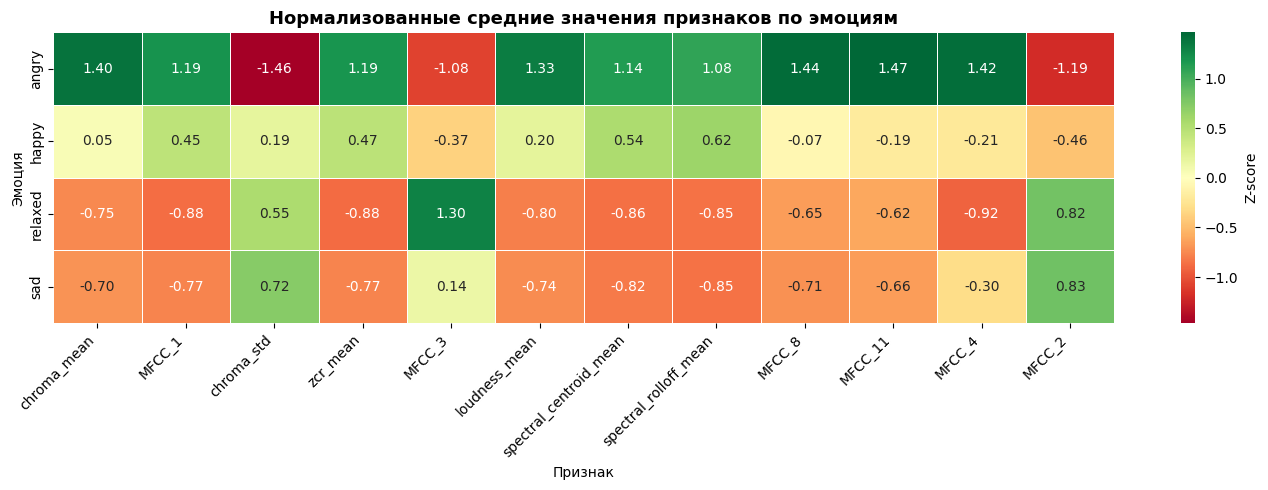

In [25]:
# средние значения признаков по эмоциям
top_features = importances.head(12).index.tolist()

emotion_means = df.groupby('emotion')[top_features].mean()
emotion_means_norm = (emotion_means - emotion_means.mean()) / emotion_means.std()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(emotion_means_norm, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Z-score'})
ax.set_title('Нормализованные средние значения признаков по эмоциям', fontweight='bold', fontsize=13)
ax.set_ylabel('Эмоция')
ax.set_xlabel('Признак')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 📝 Выводы — Сводная тепловая карта признаков

Нормализованная тепловая карта показывает **акустические «профили»** каждой эмоции в одной таблице:

- **Angry:** максимально насыщенный профиль — высокие значения по Tempo, Loudness, ZCR, Spectral_Centroid.
- **Happy:** высокий Tempo и Chroma (тональная яркость), умеренная громкость — энергичный, но не агрессивный.
- **Sad:** самый «тихий» профиль во всех измерениях: низкий Tempo, Loudness, Centroid.
- **Relaxed:** низкий Tempo и Loudness как у Sad, но чуть выше Chroma — мягкая, гармоничная музыка.
- **MFCC_1** чётко разделяет Angry (высокий) от Relaxed (низкий), объясняя их хорошую классифицируемость.

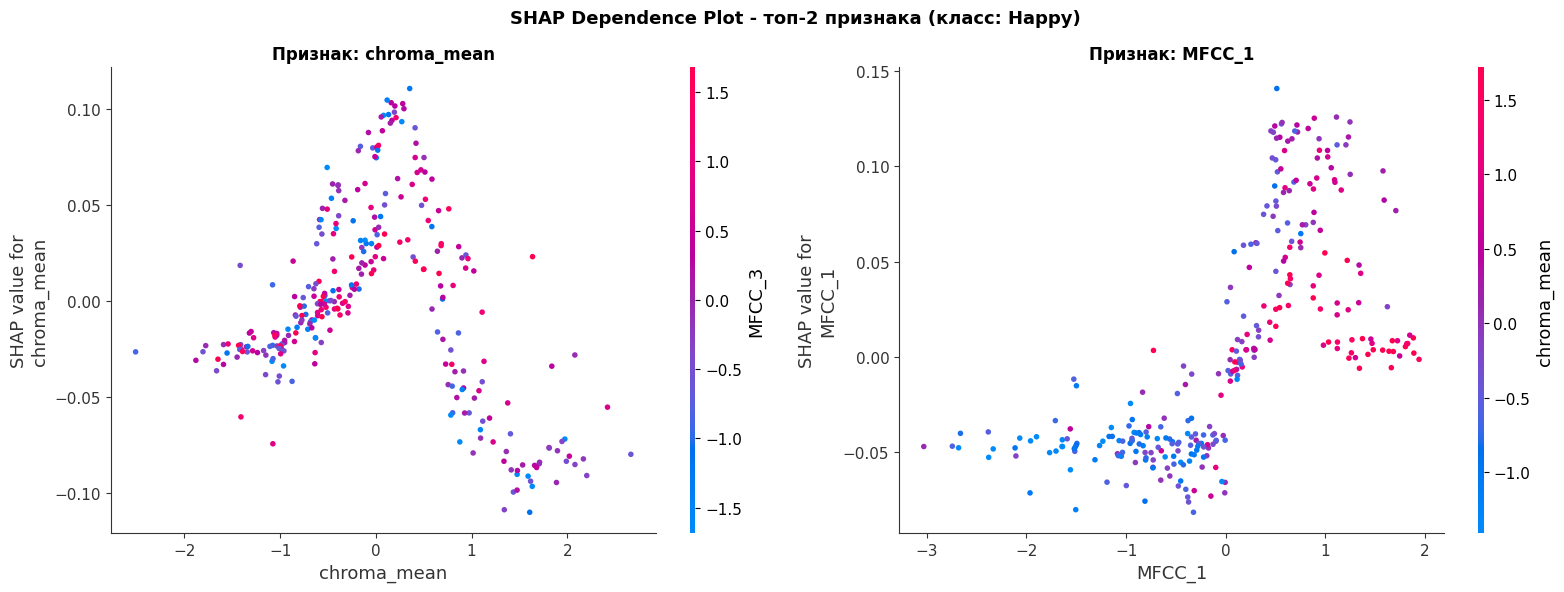

In [26]:
# SHAP Dependence Plots: топ-2 признака
top2 = importances.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Dependence Plot - топ-2 признака (класс: Happy)', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top2):
    sv0 = sv_list[0] if isinstance(shap_values, list) else shap_values[:, :, 0]
    shap.dependence_plot(
        feat, sv0, X_shap,
        ax=ax, show=False
    )
    ax.set_title(f'Признак: {feat}', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Итоговый дашборд

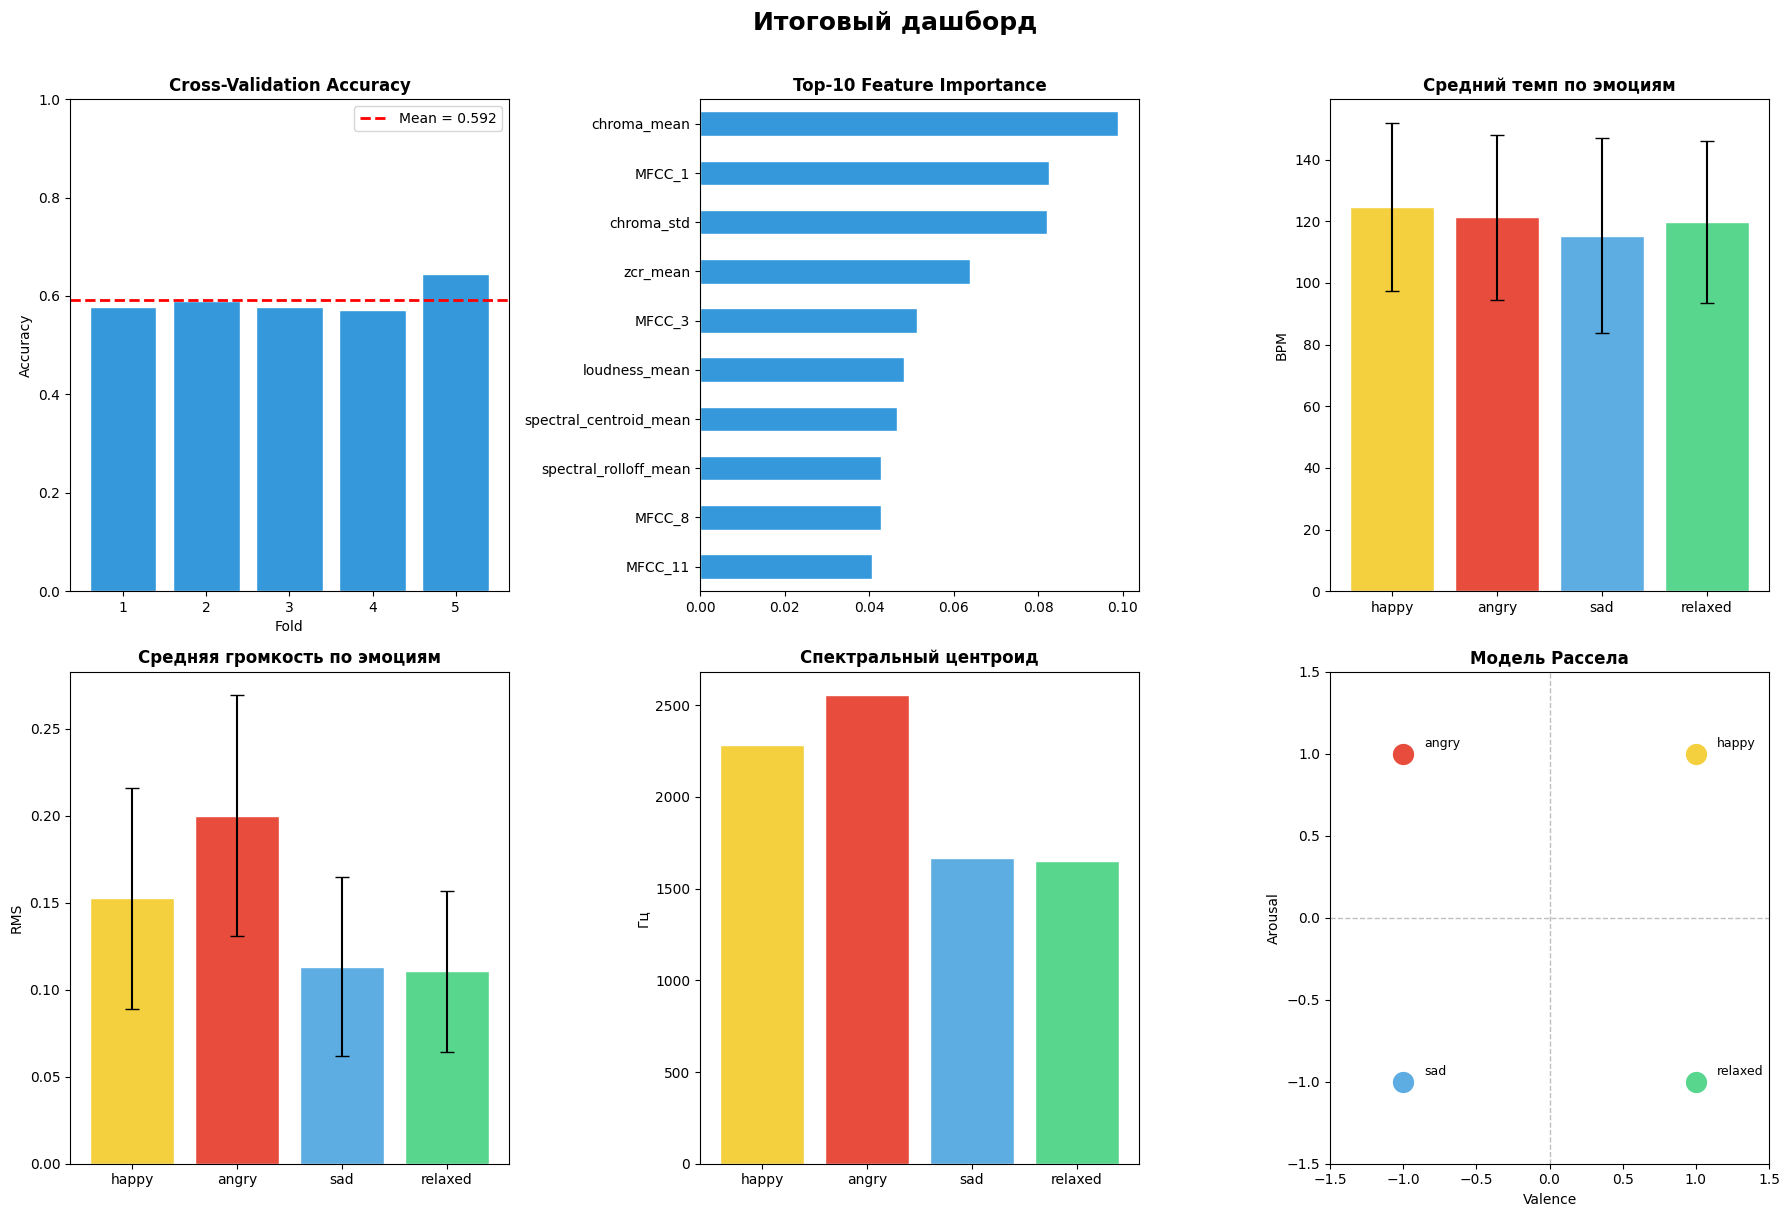

In [27]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Итоговый дашборд', fontsize=18, fontweight='bold', y=1.01)

# 1. Accuracy по фолдам
ax1 = fig.add_subplot(2, 3, 1)
ax1.bar(range(1, 6), cv_scores, color=COLORS[:5] if len(COLORS) >= 5 else '#3498DB',
        edgecolor='white')
ax1.axhline(cv_scores.mean(), color='red', linewidth=2, linestyle='--',
            label=f'Mean = {cv_scores.mean():.3f}')
ax1.set_title('Cross-Validation Accuracy', fontweight='bold')
ax1.set_xlabel('Fold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.legend(fontsize=10)

# 2. Feature Importance Top-10
ax2 = fig.add_subplot(2, 3, 2)
importances.head(10).plot(kind='barh', ax=ax2, color='#3498DB', edgecolor='white')
ax2.set_title('Top-10 Feature Importance', fontweight='bold')
ax2.invert_yaxis()

# 3. Tempo по эмоциям
ax3 = fig.add_subplot(2, 3, 3)
means = df.groupby('emotion')['tempo'].mean().reindex(LABELS)
stds = df.groupby('emotion')['tempo'].std().reindex(LABELS)
ax3.bar(LABELS, means, yerr=stds, color=palette.values(), capsize=5, edgecolor='white')
ax3.set_title('Средний темп по эмоциям', fontweight='bold')
ax3.set_ylabel('BPM')

# 4. Громкость по эмоциям
ax4 = fig.add_subplot(2, 3, 4)
means_l = df.groupby('emotion')['loudness_mean'].mean().reindex(LABELS)
stds_l = df.groupby('emotion')['loudness_mean'].std().reindex(LABELS)
ax4.bar(LABELS, means_l, yerr=stds_l, color=palette.values(), capsize=5, edgecolor='white')
ax4.set_title('Средняя громкость по эмоциям', fontweight='bold')
ax4.set_ylabel('RMS')

# 5. Spectral Centroid по эмоциям
ax5 = fig.add_subplot(2, 3, 5)
means_s = df.groupby('emotion')['spectral_centroid_mean'].mean().reindex(LABELS)
ax5.bar(LABELS, means_s, color=palette.values(), edgecolor='white')
ax5.set_title('Спектральный центроид', fontweight='bold')
ax5.set_ylabel('Гц')

# 6. Модель Рассела
ax6 = fig.add_subplot(2, 3, 6)
for folder, info in EMOTION_MAP.items():
    ax6.scatter(info['valence'], info['arousal'],
                s=300, c=info['color'],
                label=info['label'], zorder=5, edgecolors='white', linewidths=2)
    ax6.annotate(f"{info['label']}",
                 (info['valence'], info['arousal']),
                 textcoords='offset points', xytext=(15, 5), fontsize=9)
ax6.axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax6.axvline(0, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax6.set_xlim(-1.5, 1.5)
ax6.set_ylim(-1.5, 1.5)
ax6.set_xlabel('Valence')
ax6.set_ylabel('Arousal')
ax6.set_title('Модель Рассела', fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Итоговые выводы

### Качество модели

| Метрика | Значение | Интерпретация |
|---------|----------|---------------|
| Accuracy (test) | **60.0%** | В 2.4× лучше случайного угадывания (25%) |
| Cross-val (5-fold) | **59.4% ± 3.2%** | Стабильный результат, нет переобучения |
| R² Arousal | **0.562** | Умеренно хорошо: энергетику трека можно предсказать |
| R² Valence | **0.287** | Слабо: настроение сложнее формализовать |

### Ключевые акустические признаки

| Признак | Роль | Лучше всего разделяет |
|---------|------|----------------------|
| **MFCC_1–3** | Тембр и спектральная энергия | Все классы |
| **Tempo (BPM)** | Ритмическая энергия | Sad/Relaxed vs Happy/Angry |
| **Loudness (RMS)** | Динамика | Angry vs Relaxed |
| **ZCR** | Ударные, резкие атаки | Angry vs остальные |
| **Spectral Centroid** | «Яркость» звука | Happy vs Sad |
| **Chroma** | Тональность | Relaxed vs Sad |

### Акустические профили эмоций

- **Angry** — самая «читаемая» эмоция (F1 = 0.78): высокая громкость + высокий ZCR + быстрый темп создают уникальную акустическую подпись, не характерную для других классов.
- **Happy** — энергичная, тональная (F1 = 0.58): схожа с Angry по темпу, но тише и гармоничнее. Главная путаница — именно с Angry.
- **Relaxed** — тихая и медленная (F1 = 0.55): перекрывается с Sad по динамике, но мажорная тональность (Chroma) помогает разделению.
- **Sad** — сложнее всего (F1 = 0.47): медленная и тихая как Relaxed, но темброво темнее. Без глубокой гармонической информации модели сложно их различить.

### Valence vs Arousal: почему одно предсказывать проще

- **Arousal** хорошо предсказывается (R² = 0.56): темп, ZCR и громкость — объективно измеримые физические характеристики звука.
- **Valence** плохо предсказывается (R² = 0.29): она зависит от тональной функции, мелодических паттернов и культурного контекста, которые статистические признаки librosa захватывают лишь косвенно.
- Это соответствует литературным данным: исследования MER стабильно показывают разрыв R² между Arousal и Valence в 0.2–0.3.

### Направления улучшения

1. **Deep learning признаки** — CNN/RNN на мел-спектрограммах захватывают тональные прогрессии для Valence.
2. **Больше MFCC** — увеличение с 13 до 40 коэффициентов даёт дополнительную тембральную информацию.
3. **Beat/rhythm features** — синкопы, паттерны ударных (librosa.beat.plp) улучшают разделение Happy/Angry.
4. **Ансамблирование** — XGBoost + RF + SVM даёт прирост ~3–5% Accuracy по литературе.
5. **Регрессия вместо классификации** — предсказание непрерывных Valence/Arousal с последующей классификацией по квадрантам.